**Sleep–HRV Interaction Analysis Using Wearable Data**

This project analyzes the relationship between sleep metrics collected from wearable data and next-day heart rate variability (HRV). The main goal is to determine which sleep metric is most informative for next-day HRV.

The main input variables are:

- deep sleep duration
- REM sleep duration
- sleep efficiency

The target variable is next-day HRV measured in milliseconds.

Heart rate variability (HRV) measures variation in time between consecutive heartbeats and is commonly used as an indicator of autonomic nervous system regulation, recovery and physiological stress. Higher HRV is often associated with better recovery and parasympathetic activity, while lower HRV can be related to stress, fatigue, illness, or poor recovery.
Sleep is also closely related to recovery.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DATA_DIR = Path(".")

VITAL_PATH = DATA_DIR / "Vital Signs-Didiconn-2025-11-01-2026-05-04.csv"
SLEEP_PATH = DATA_DIR / "Sleep-Didiconn-2025-11-01-2026-05-04.csv"
ACTIVITY_PATH = DATA_DIR / "Activity-Didiconn-2025-11-01-2026-05-04.csv"

FIG_DIR = Path("figures_cda")
FIG_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True

def save_and_show(filename):
    if SAVE_FIGURES:
        plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [65]:
COLORS = {
    "blue": "#1F5D7A",
    "light_blue": "#8FAFC0",
    "green": "#3F7D5C",
    "red": "#A94442",
    "orange": "#B8792A",
    "purple": "#5D4B8B",
    "navy": "#1D2D44",
    "gray": "#5F6368",
    "light_gray": "#D9DEE7",
    "background": "#F7F8FA",
    "dark": "#202124"
}

FEATURE_COLORS = {
    "deep_sleep_min": COLORS["blue"],
    "rem_sleep_min": COLORS["purple"],
    "sleep_efficiency_pct": COLORS["green"],
    "next_day_hrv_ms": COLORS["navy"],
    "awake_min": COLORS["orange"],
    "time_asleep_min": "#2F6F73",
    "light_sleep_min": COLORS["gray"],
    "steps_prev_day": "#6B705C",
    "calories_prev_day": "#8A6F3D",
    "avg_heart_rate_bpm": COLORS["red"],
    "avg_spo2_pct": COLORS["blue"]
}

CLUSTER_COLORS = [
    "#1F5D7A",
    "#3F7D5C",
    "#B8792A",
    "#5D4B8B",
    "#A94442"
]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": COLORS["background"],
    "axes.edgecolor": "#B8C0CC",
    "axes.labelcolor": COLORS["dark"],
    "xtick.color": COLORS["dark"],
    "ytick.color": COLORS["dark"],
    "text.color": COLORS["dark"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.facecolor": "white",
    "legend.edgecolor": "#B8C0CC"
})

def polish_axes(grid_axis="y"):
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#B8C0CC")
    ax.spines["bottom"].set_color("#B8C0CC")
    ax.grid(True, axis=grid_axis, color=COLORS["light_gray"], linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

def signed_colors(values):
    return [COLORS["blue"] if value >= 0 else COLORS["red"] for value in values]

def outlier_colors(values):
    return [COLORS["orange"] if value > 0 else COLORS["green"] for value in values]

def model_metric_colors(labels, values):
    best_value = min(values)
    final_colors = []

    for label, value in zip(labels, values):
        if value == best_value:
            final_colors.append(COLORS["blue"])
        elif "Baseline" in str(label):
            final_colors.append(COLORS["gray"])
        else:
            final_colors.append(COLORS["orange"])

    return final_colors

def feature_bar_colors(features):
    return [FEATURE_COLORS.get(feature, COLORS["blue"]) for feature in features]

In [66]:
vital_raw = pd.read_csv(VITAL_PATH)
sleep_raw = pd.read_csv(SLEEP_PATH)
activity_raw = pd.read_csv(ACTIVITY_PATH)

for name, df in [
    ("Vital Signs", vital_raw),
    ("Sleep", sleep_raw),
    ("Activity", activity_raw)
]:
    print(f"\n{name}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(df.columns.tolist())
    display(df.head())


Vital Signs: 160 rows, 10 columns
['Date', 'Avg. Heart Rate(bpm)', 'Min. Heart Rate(bpm)', 'Max. Heart Rate(bpm)', 'Avg. Spo2(%)', 'Min. Spo2(%)', 'Max. Spo2(%)', 'Avg. HRV(ms)', 'Min. HRV(ms)', 'Max. HRV(ms)']


,Date,Avg. Heart Rate(bpm),Min. Heart Rate(bpm),Max. Heart Rate(bpm),Avg. Spo2(%),Min. Spo2(%),Max. Spo2(%),Avg. HRV(ms),Min. HRV(ms),Max. HRV(ms)
0,2025-11-25,75,54,147,96%,92%,99%,48,14,131
1,2025-11-26,70,47,123,96%,93%,100%,52,15,115
2,2025-11-27,67,44,131,95%,92%,98%,59,11,133
3,2025-11-28,68,42,144,96%,91%,98%,51,17,152
4,2025-11-29,67,46,113,96%,92%,98%,52,17,128



Sleep: 168 rows, 10 columns
['Start Time', 'End Time', 'Falling Asleep Time', 'Wake-up time', 'Sleep Time Ratio(%)', 'Time Asleep(min)', 'Sleep Stages - Awake(min)', 'Sleep Stages - REM(min)', 'Sleep Stages - Light Sleep(min)', 'Sleep Stages - Deep Sleep(min)']


,Start Time,End Time,Falling Asleep Time,Wake-up time,Sleep Time Ratio(%),Time Asleep(min),Sleep Stages - Awake(min),Sleep Stages - REM(min),Sleep Stages - Light Sleep(min),Sleep Stages - Deep Sleep(min)
0,2025-11-25 23:15:46,2025-11-26 08:48:18,2025-11-25 23:48:18,2025-11-26 08:08:18,75.00%,428,72,138,180,110
1,2025-11-27 01:43:30,2025-11-27 08:46:01,2025-11-27 02:33:31,2025-11-27 08:33:31,82.00%,345,15,135,115,95
2,2025-11-28 00:03:48,2025-11-28 08:51:18,2025-11-28 00:23:48,2025-11-28 08:48:48,86.00%,455,50,140,225,90
3,2025-11-29 00:56:19,2025-11-29 09:38:49,2025-11-29 01:56:19,2025-11-29 09:11:19,81.00%,423,12,145,188,90
4,2025-11-30 01:23:55,2025-11-30 10:13:55,2025-11-30 02:06:25,2025-11-30 10:06:25,88.00%,467,13,150,212,105



Activity: 160 rows, 3 columns
['Date', 'Steps', 'Calories(kcal)']


,Date,Steps,Calories(kcal)
0,2025-11-25,5180,1097
1,2025-11-26,5186,1613
2,2025-11-27,2774,1592
3,2025-11-28,4858,1598
4,2025-11-29,3478,1560


In [67]:
print("Vital signs data types:")
display(vital_raw.dtypes)

print("\nsleep data types:")
display(sleep_raw.dtypes)

print("\nactivity data types:")
display(activity_raw.dtypes)

print("\nmissing values in raw datasets:")
raw_missing = pd.concat(
    {
        "vital": vital_raw.isna().sum(),
        "sleep": sleep_raw.isna().sum(),
        "activity": activity_raw.isna().sum()
    },
    axis=1
).fillna(0).astype(int)

display(raw_missing)

print("\nduplicate rows:")
print("vital signs:", vital_raw.duplicated().sum())
print("sleep:", sleep_raw.duplicated().sum())
print("activity:", activity_raw.duplicated().sum())

Vital signs data types:


,0
Date,object
Avg. Heart Rate(bpm),int64
Min. Heart Rate(bpm),int64
Max. Heart Rate(bpm),int64
Avg. Spo2(%),object
Min. Spo2(%),object
Max. Spo2(%),object
Avg. HRV(ms),int64
Min. HRV(ms),int64
Max. HRV(ms),int64



sleep data types:


,0
Start Time,object
End Time,object
Falling Asleep Time,object
Wake-up time,object
Sleep Time Ratio(%),object
Time Asleep(min),int64
Sleep Stages - Awake(min),int64
Sleep Stages - REM(min),int64
Sleep Stages - Light Sleep(min),int64
Sleep Stages - Deep Sleep(min),int64



activity data types:


,0
Date,object
Steps,int64
Calories(kcal),int64



missing values in raw datasets:


,vital,sleep,activity
Date,0,0,0
Avg. Heart Rate(bpm),0,0,0
Min. Heart Rate(bpm),0,0,0
Max. Heart Rate(bpm),0,0,0
Avg. Spo2(%),0,0,0
Min. Spo2(%),0,0,0
Max. Spo2(%),0,0,0
Avg. HRV(ms),0,0,0
Min. HRV(ms),0,0,0
Max. HRV(ms),0,0,0



duplicate rows:
vital signs: 0
sleep: 0
activity: 0


In [68]:
def percent_to_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        x = x.replace("%", "").strip()
    return pd.to_numeric(x, errors="coerce")


def minutes_between(start, end):
    return (end-start).dt.total_seconds()/60

In [69]:
vital = vital_raw.copy()

vital["date"] = pd.to_datetime(vital["Date"], errors="coerce")

for col in ["Avg. Spo2(%)", "Min. Spo2(%)", "Max. Spo2(%)"]:
    vital[col] = vital[col].apply(percent_to_float)

vital = vital.rename(
    columns={
        "Avg. Heart Rate(bpm)": "avg_heart_rate_bpm",
        "Min. Heart Rate(bpm)": "min_heart_rate_bpm",
        "Max. Heart Rate(bpm)": "max_heart_rate_bpm",
        "Avg. Spo2(%)": "avg_spo2_pct",
        "Min. Spo2(%)": "min_spo2_pct",
        "Max. Spo2(%)": "max_spo2_pct",
        "Avg. HRV(ms)": "next_day_hrv_ms",
        "Min. HRV(ms)": "min_hrv_ms",
        "Max. HRV(ms)": "max_hrv_ms"
    }
)
vital=vital.drop(columns=["Date"])
vital=vital.sort_values("date").reset_index(drop=True)
display(vital.head())
display(vital.info())

,avg_heart_rate_bpm,min_heart_rate_bpm,max_heart_rate_bpm,avg_spo2_pct,min_spo2_pct,max_spo2_pct,next_day_hrv_ms,min_hrv_ms,max_hrv_ms,date
0,75,54,147,96,92,99,48,14,131,2025-11-25
1,70,47,123,96,93,100,52,15,115,2025-11-26
2,67,44,131,95,92,98,59,11,133,2025-11-27
3,68,42,144,96,91,98,51,17,152,2025-11-28
4,67,46,113,96,92,98,52,17,128,2025-11-29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   avg_heart_rate_bpm  160 non-null    int64         
 1   min_heart_rate_bpm  160 non-null    int64         
 2   max_heart_rate_bpm  160 non-null    int64         
 3   avg_spo2_pct        160 non-null    int64         
 4   min_spo2_pct        160 non-null    int64         
 5   max_spo2_pct        160 non-null    int64         
 6   next_day_hrv_ms     160 non-null    int64         
 7   min_hrv_ms          160 non-null    int64         
 8   max_hrv_ms          160 non-null    int64         
 9   date                160 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(9)
memory usage: 12.6 KB


None

In [70]:
activity = activity_raw.copy()
activity["date_original"] = pd.to_datetime(activity["Date"], errors="coerce")
activity = activity.rename(
    columns={
        "Steps": "steps",
        "Calories(kcal)": "calories_kcal"
    }
)
activity = activity.drop(columns=["Date"])
activity = activity.sort_values("date_original").reset_index(drop=True)
activity_prev = activity.copy()
activity_prev["date"] = activity_prev["date_original"] + pd.Timedelta(days=1)
activity_prev = activity_prev.rename(
    columns={
        "steps": "steps_prev_day",
        "calories_kcal": "calories_prev_day"
    }
)
activity_prev = activity_prev[["date","steps_prev_day", "calories_prev_day"]]
display(activity.head())
display(activity_prev.head())

,steps,calories_kcal,date_original
0,5180,1097,2025-11-25
1,5186,1613,2025-11-26
2,2774,1592,2025-11-27
3,4858,1598,2025-11-28
4,3478,1560,2025-11-29


,date,steps_prev_day,calories_prev_day
0,2025-11-26,5180,1097
1,2025-11-27,5186,1613
2,2025-11-28,2774,1592
3,2025-11-29,4858,1598
4,2025-11-30,3478,1560


In [71]:
sleep = sleep_raw.copy()
for col in ["Start Time", "End Time", "Falling Asleep Time", "Wake-up time"]:
    sleep[col] = pd.to_datetime(sleep[col], errors="coerce")

sleep["sleep_time_ratio_pct_raw"] = sleep["Sleep Time Ratio(%)"].apply(percent_to_float)
sleep["wake_date"] = sleep["Wake-up time"].dt.normalize()
sleep["time_in_bed_min"] = minutes_between(sleep["Start Time"], sleep["End Time"])
sleep = sleep.rename(
    columns={
        "Time Asleep(min)": "time_asleep_min",
        "Sleep Stages - Awake(min)": "awake_min",
        "Sleep Stages - REM(min)": "rem_sleep_min",
        "Sleep Stages - Light Sleep(min)": "light_sleep_min",
        "Sleep Stages - Deep Sleep(min)": "deep_sleep_min"
    }
)

sleep["sleep_efficiency_pct_computed"] = 100*sleep["time_asleep_min"]/sleep["time_in_bed_min"]
sleep["is_sleep_duration_valid"] = sleep["time_asleep_min"].between(0, 24*60)
sleep["is_efficiency_valid"] = sleep["sleep_efficiency_pct_computed"].between(0,100)

display(
    sleep[
        [
            "wake_date",
            "time_asleep_min",
            "awake_min",
            "rem_sleep_min",
            "deep_sleep_min",
            "time_in_bed_min",
            "sleep_efficiency_pct_computed",
            "sleep_time_ratio_pct_raw"
        ]
    ].head()
)
print("Invalid sleep duration rows:", (~sleep["is_sleep_duration_valid"]).sum())
print("Invalid efficiency rows:", (~sleep["is_efficiency_valid"]).sum())
print("Raw sleep records:", len(sleep))
print("Unique wake dates:", sleep["wake_date"].nunique())
print("Wake dates with more than one sleep record:", sleep["wake_date"].duplicated().sum())

,wake_date,time_asleep_min,awake_min,rem_sleep_min,deep_sleep_min,time_in_bed_min,sleep_efficiency_pct_computed,sleep_time_ratio_pct_raw
0,2025-11-26,428,72,138,110,572.533333,74.755473,75.0
1,2025-11-27,345,15,135,95,422.516667,81.653584,82.0
2,2025-11-28,455,50,140,90,527.500000,86.255924,86.0
3,2025-11-29,423,12,145,90,522.500000,80.956938,81.0
4,2025-11-30,467,13,150,105,530.000000,88.113208,88.0


Invalid sleep duration rows: 0
Invalid efficiency rows: 0
Raw sleep records: 168
Unique wake dates: 158
Wake dates with more than one sleep record: 10


In [72]:
sleep_agg = (
    sleep.groupby("wake_date")
    .agg(
        sleep_records=("wake_date", "size"),
        sleep_start=("Start Time", "min"),
        wake_time=("Wake-up time", "max"),
        time_in_bed_min=("time_in_bed_min", "sum"),
        time_asleep_min=("time_asleep_min", "sum"),
        awake_min=("awake_min", "sum"),
        rem_sleep_min=("rem_sleep_min", "sum"),
        light_sleep_min=("light_sleep_min", "sum"),
        deep_sleep_min=("deep_sleep_min", "sum"),
        sleep_efficiency_pct_raw_mean=("sleep_time_ratio_pct_raw", "mean")
    )
    .reset_index()
    .rename(columns={"wake_date": "date"})
)

#sleep efficiency after aggregation
sleep_agg["sleep_efficiency_pct"] = (
    100 * sleep_agg["time_asleep_min"] / sleep_agg["time_in_bed_min"]
)

sleep_agg["rem_sleep_pct_of_asleep"] = (
    100 * sleep_agg["rem_sleep_min"] / sleep_agg["time_asleep_min"]
)
sleep_agg["deep_sleep_pct_of_asleep"] = (
    100 * sleep_agg["deep_sleep_min"] / sleep_agg["time_asleep_min"]
)
sleep_agg["awake_pct_of_time_in_bed"] = (
    100 * sleep_agg["awake_min"] / sleep_agg["time_in_bed_min"]
)
display(sleep_agg.head())
print("Aggregated sleep shape:", sleep_agg.shape)

,date,sleep_records,sleep_start,wake_time,time_in_bed_min,time_asleep_min,awake_min,rem_sleep_min,light_sleep_min,deep_sleep_min,sleep_efficiency_pct_raw_mean,sleep_efficiency_pct,rem_sleep_pct_of_asleep,deep_sleep_pct_of_asleep,awake_pct_of_time_in_bed
0,2025-11-26,1,2025-11-25 23:15:46,2025-11-26 08:08:18,572.533333,428,72,138,180,110,75.0,74.755473,32.242991,25.700935,12.575687
1,2025-11-27,1,2025-11-27 01:43:30,2025-11-27 08:33:31,422.516667,345,15,135,115,95,82.0,81.653584,39.130435,27.536232,3.550156
2,2025-11-28,1,2025-11-28 00:03:48,2025-11-28 08:48:48,527.500000,455,50,140,225,90,86.0,86.255924,30.769231,19.780220,9.478673
3,2025-11-29,1,2025-11-29 00:56:19,2025-11-29 09:11:19,522.500000,423,12,145,188,90,81.0,80.956938,34.278960,21.276596,2.296651
4,2025-11-30,1,2025-11-30 01:23:55,2025-11-30 10:06:25,530.000000,467,13,150,212,105,88.0,88.113208,32.119914,22.483940,2.452830


Aggregated sleep shape: (158, 15)


In [73]:
sleep_vital = pd.merge(
    sleep_agg,
    vital,
    on="date",
    how="inner"
)
final_df = pd.merge(
    sleep_vital,
    activity_prev,
    on="date",
    how="left"
)
final_df = final_df.sort_values("date").reset_index(drop=True)
core_features = [
    "deep_sleep_min",
    "rem_sleep_min",
    "sleep_efficiency_pct"
]

activity_features = [
    "steps_prev_day",
    "calories_prev_day"
]
target = "next_day_hrv_ms"
model_df = final_df[
    ["date"] +
    core_features +
    [target] +
    activity_features +
    [
        "time_asleep_min",
        "awake_min",
        "light_sleep_min",
        "deep_sleep_pct_of_asleep",
        "rem_sleep_pct_of_asleep",
        "awake_pct_of_time_in_bed",
        "sleep_records",
        "avg_heart_rate_bpm",
        "avg_spo2_pct"
    ]
].copy()
print("final merged dataset:", final_df.shape)
print("model ready dataset:", model_df.shape)
print("date range:", model_df["date"].min().date(), "to", model_df["date"].max().date())
display(model_df.head())

final merged dataset: (157, 26)
model ready dataset: (157, 16)
date range: 2025-11-26 to 2026-05-03


,date,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,next_day_hrv_ms,steps_prev_day,calories_prev_day,time_asleep_min,awake_min,light_sleep_min,deep_sleep_pct_of_asleep,rem_sleep_pct_of_asleep,awake_pct_of_time_in_bed,sleep_records,avg_heart_rate_bpm,avg_spo2_pct
0,2025-11-26,110,138,74.755473,52,5180,1097,428,72,180,25.700935,32.242991,12.575687,1,70,96
1,2025-11-27,95,135,81.653584,59,5186,1613,345,15,115,27.536232,39.130435,3.550156,1,67,95
2,2025-11-28,90,140,86.255924,51,2774,1592,455,50,225,19.780220,30.769231,9.478673,1,68,96
3,2025-11-29,90,145,80.956938,52,4858,1598,423,12,188,21.276596,34.278960,2.296651,1,67,96
4,2025-11-30,105,150,88.113208,59,3478,1560,467,13,212,22.483940,32.119914,2.452830,1,67,96


In [74]:
required_model_columns = ["date"] + core_features + [target]
model_df_core = model_df[required_model_columns].dropna().copy()
print("Rows before dropping missing values in sleep HRV variables:", len(model_df))
print("Rows after dropping missing values:", len(model_df_core))
print("\nMissing values")
display(model_df[required_model_columns].isna().sum())

Rows before dropping missing values in sleep HRV variables: 157
Rows after dropping missing values: 157

Missing values


,0
date,0
deep_sleep_min,0
rem_sleep_min,0
sleep_efficiency_pct,0
next_day_hrv_ms,0


,dataset,rows,date_start,date_end,missing_total,duplicate_rows
0,Vital Signs,160,2025-11-25,2026-05-03,0,0
1,Sleep raw,168,2025-11-26,2026-05-04,0,0
2,Sleep aggregated,158,2025-11-26,2026-05-04,0,0
3,Activity,160,2025-11-25,2026-05-03,0,0
4,Final model-ready,157,2025-11-26,2026-05-03,0,0


Missing values in dataset:


,0


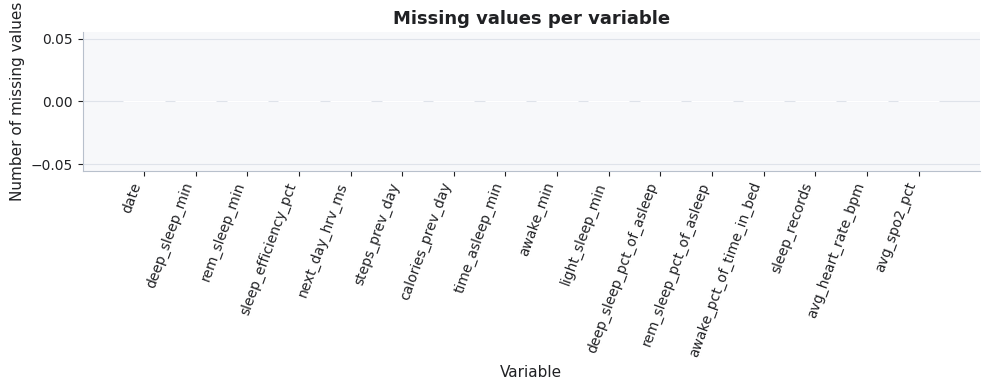

In [75]:
quality_summary = pd.DataFrame(
    {
        "dataset": [
            "Vital Signs",
            "Sleep raw",
            "Sleep aggregated",
            "Activity",
            "Final model-ready"
        ],
        "rows": [
            len(vital),
            len(sleep),
            len(sleep_agg),
            len(activity),
            len(model_df)
        ],
        "date_start": [
            vital["date"].min(),
            sleep["wake_date"].min(),
            sleep_agg["date"].min(),
            activity["date_original"].min(),
            model_df["date"].min()
        ],
        "date_end": [
            vital["date"].max(),
            sleep["wake_date"].max(),
            sleep_agg["date"].max(),
            activity["date_original"].max(),
            model_df["date"].max()
        ],
        "missing_total": [
            vital.isna().sum().sum(),
            sleep.isna().sum().sum(),
            sleep_agg.isna().sum().sum(),
            activity.isna().sum().sum(),
            model_df.isna().sum().sum()
        ],
        "duplicate_rows": [
            vital.duplicated().sum(),
            sleep.duplicated().sum(),
            sleep_agg.duplicated().sum(),
            activity.duplicated().sum(),
            model_df.duplicated().sum()
        ]
    }
)
display(quality_summary)
missing_model = model_df.isna().sum().sort_values(ascending=False)
print("Missing values in dataset:")
display(missing_model[missing_model > 0])

plt.figure(figsize=(10, 4))
missing_values_to_plot = missing_model.copy()
colors = [COLORS["red"] if value > 0 else COLORS["green"] for value in missing_values_to_plot.values]
plt.bar(
    missing_values_to_plot.index,
    missing_values_to_plot.values,
    color=colors,
    edgecolor="white",
    linewidth=0.8
)
plt.title("Missing values per variable")
plt.ylabel("Number of missing values")
plt.xlabel("Variable")
plt.xticks(rotation=70, ha="right")
polish_axes()
plt.tight_layout()
save_and_show("missing_values_model_ready.png")

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
11,calories_prev_day,1575.000000,1727.000000,152.000000,1347.000000,1955.000000,12,7.643312
4,time_asleep_min,447.000000,558.000000,111.000000,280.500000,724.500000,5,3.184713
13,avg_spo2_pct,95.000000,96.000000,1.000000,93.500000,97.500000,5,3.184713
9,awake_pct_of_time_in_bed,4.426230,9.750000,5.323770,-3.559426,17.735656,4,2.547771
5,awake_min,23.000000,61.000000,38.000000,-34.000000,118.000000,3,1.910828
0,deep_sleep_min,100.000000,135.000000,35.000000,47.500000,187.500000,3,1.910828
6,light_sleep_min,200.000000,280.000000,80.000000,80.000000,400.000000,3,1.910828
8,rem_sleep_pct_of_asleep,23.339318,32.006920,8.667603,10.337914,45.008324,2,1.273885
10,steps_prev_day,3550.000000,6239.000000,2689.000000,-483.500000,10272.500000,2,1.273885
7,deep_sleep_pct_of_asleep,21.375465,26.378897,5.003432,13.870316,33.884045,2,1.273885


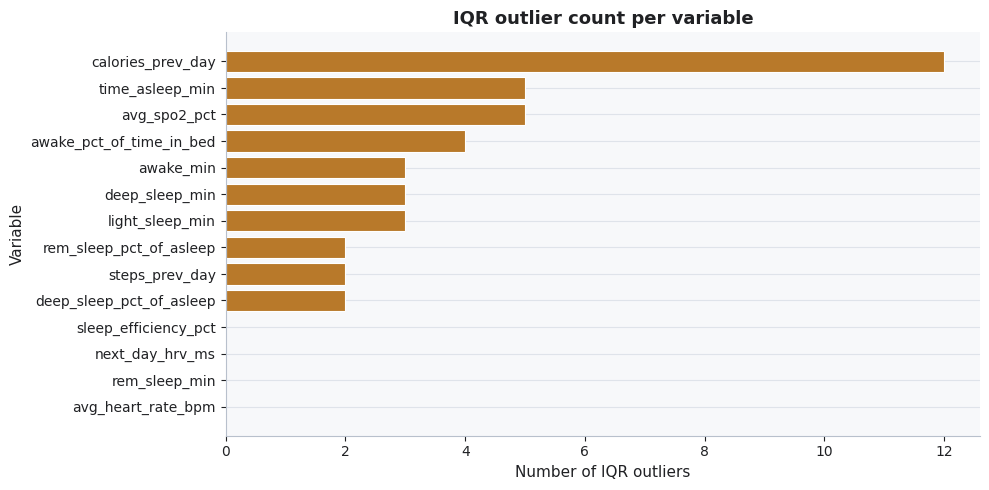

In [76]:
#Outlier analysis using IQR and Z-score
from scipy.stats import zscore
numeric_for_outliers = [
    "deep_sleep_min",
    "rem_sleep_min",
    "sleep_efficiency_pct",
    "next_day_hrv_ms",
    "time_asleep_min",
    "awake_min",
    "light_sleep_min",
    "deep_sleep_pct_of_asleep",
    "rem_sleep_pct_of_asleep",
    "awake_pct_of_time_in_bed",
    "steps_prev_day",
    "calories_prev_day",
    "avg_heart_rate_bpm",
    "avg_spo2_pct"
]
numeric_for_outliers = [col for col in numeric_for_outliers if col in model_df.columns]
iqr_rows = []
for col in numeric_for_outliers:
    clean_col = pd.to_numeric(model_df[col], errors="coerce").dropna()

    q1 = clean_col.quantile(0.25)
    q3 = clean_col.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (model_df[col] < lower_bound) | (model_df[col] > upper_bound)
    iqr_rows.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_percent": 100 * outlier_mask.sum() / model_df[col].notna().sum()
    })

iqr_report = pd.DataFrame(iqr_rows).sort_values("outlier_count", ascending=False)
display(iqr_report)
plt.figure(figsize=(10, 5))
plt.barh(
    iqr_report["variable"],
    iqr_report["outlier_count"],
    color=outlier_colors(iqr_report["outlier_count"]),
    edgecolor="white",
    linewidth=0.8
)
plt.title("IQR outlier count per variable")
plt.xlabel("Number of IQR outliers")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show("iqr_outlier_counts.png")

,variable,z_outlier_count_abs_gt_3,z_outlier_percent
11,calories_prev_day,4,2.547771
5,awake_min,2,1.273885
8,rem_sleep_pct_of_asleep,2,1.273885
10,steps_prev_day,2,1.273885
7,deep_sleep_pct_of_asleep,2,1.273885
0,deep_sleep_min,1,0.636943
6,light_sleep_min,1,0.636943
4,time_asleep_min,1,0.636943
1,rem_sleep_min,0,0.000000
3,next_day_hrv_ms,0,0.000000


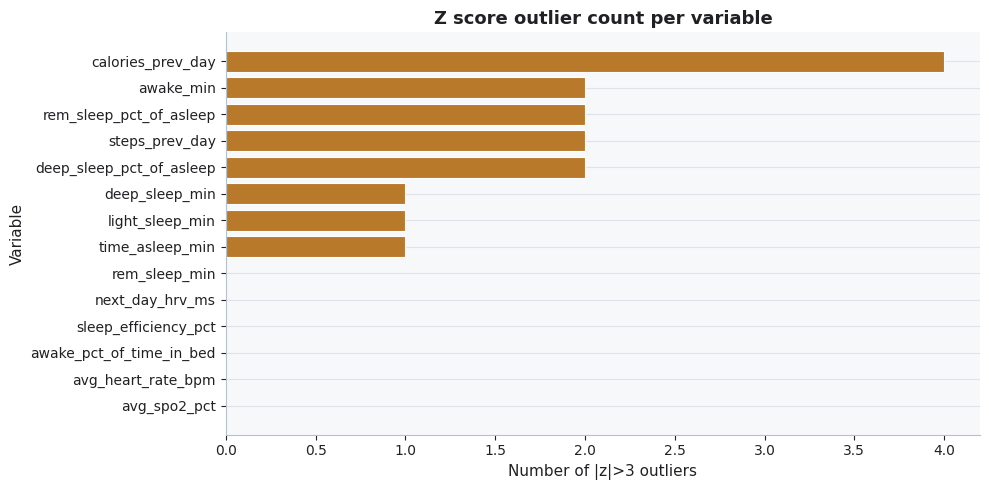

In [77]:
#Z-score outlier analysis

z_rows = []
for col in numeric_for_outliers:
    clean_col = pd.to_numeric(model_df[col], errors="coerce")
    z_values = pd.Series(
        zscore(clean_col, nan_policy="omit"),
        index=model_df.index
    )
    outlier_mask = z_values.abs() > 3

    z_rows.append({
        "variable": col,
        "z_outlier_count_abs_gt_3": int(outlier_mask.sum()),
        "z_outlier_percent": 100 * outlier_mask.sum() / clean_col.notna().sum()
    })

z_report = pd.DataFrame(z_rows).sort_values("z_outlier_count_abs_gt_3", ascending=False)
display(z_report)
plt.figure(figsize=(10, 5))
plt.barh(
    z_report["variable"],
    z_report["z_outlier_count_abs_gt_3"],
    color=outlier_colors(z_report["z_outlier_count_abs_gt_3"]),
    edgecolor="white",
    linewidth=0.8
)
plt.title("Z score outlier count per variable")
plt.xlabel("Number of |z|>3 outliers")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show("zscore_outlier_counts.png")

In [78]:
model_df_capped = model_df.copy()
for col in numeric_for_outliers:
    lower = iqr_report.loc[iqr_report["variable"]==col, "lower_bound"].iloc[0]
    upper = iqr_report.loc[iqr_report["variable"]==col, "upper_bound"].iloc[0]
    model_df_capped[col + "_iqr_capped"] = model_df_capped[col].clip(lower, upper)
display(model_df_capped.head())

,date,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,next_day_hrv_ms,steps_prev_day,calories_prev_day,time_asleep_min,awake_min,light_sleep_min,deep_sleep_pct_of_asleep,rem_sleep_pct_of_asleep,awake_pct_of_time_in_bed,sleep_records,avg_heart_rate_bpm,avg_spo2_pct,deep_sleep_min_iqr_capped,rem_sleep_min_iqr_capped,sleep_efficiency_pct_iqr_capped,next_day_hrv_ms_iqr_capped,time_asleep_min_iqr_capped,awake_min_iqr_capped,light_sleep_min_iqr_capped,deep_sleep_pct_of_asleep_iqr_capped,rem_sleep_pct_of_asleep_iqr_capped,awake_pct_of_time_in_bed_iqr_capped,steps_prev_day_iqr_capped,calories_prev_day_iqr_capped,avg_heart_rate_bpm_iqr_capped,avg_spo2_pct_iqr_capped
0,2025-11-26,110,138,74.755473,52,5180,1097,428,72,180,25.700935,32.242991,12.575687,1,70,96,110.0,138,74.755473,52,428.0,72,180,25.700935,32.242991,12.575687,5180.0,1347,70,96.0
1,2025-11-27,95,135,81.653584,59,5186,1613,345,15,115,27.536232,39.130435,3.550156,1,67,95,95.0,135,81.653584,59,345.0,15,115,27.536232,39.130435,3.550156,5186.0,1613,67,95.0
2,2025-11-28,90,140,86.255924,51,2774,1592,455,50,225,19.780220,30.769231,9.478673,1,68,96,90.0,140,86.255924,51,455.0,50,225,19.780220,30.769231,9.478673,2774.0,1592,68,96.0
3,2025-11-29,90,145,80.956938,52,4858,1598,423,12,188,21.276596,34.278960,2.296651,1,67,96,90.0,145,80.956938,52,423.0,12,188,21.276596,34.278960,2.296651,4858.0,1598,67,96.0
4,2025-11-30,105,150,88.113208,59,3478,1560,467,13,212,22.483940,32.119914,2.452830,1,67,96,105.0,150,88.113208,59,467.0,13,212,22.483940,32.119914,2.452830,3478.0,1560,67,96.0


In [79]:
eda_columns = (
    core_features +
    [
        target,
        "time_asleep_min",
        "awake_min",
        "light_sleep_min",
        "deep_sleep_pct_of_asleep",
        "rem_sleep_pct_of_asleep",
        "awake_pct_of_time_in_bed"
    ] +
    activity_features
)
summary_stats = model_df[eda_columns].describe().T
summary_stats["missing"] = model_df[eda_columns].isna().sum()
summary_stats["skewness"] = model_df[eda_columns].skew(numeric_only=True)
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max,missing,skewness
deep_sleep_min,157.0,119.420382,29.008206,30.000000,100.000000,120.000000,135.000000,200.000000,0,-0.007972
rem_sleep_min,157.0,135.929936,38.762114,35.000000,105.000000,135.000000,160.000000,235.000000,0,0.128601
sleep_efficiency_pct,157.0,85.750587,4.241283,74.755473,82.442250,85.972851,88.582677,95.706806,0,-0.085626
next_day_hrv_ms,157.0,41.891720,12.092369,24.000000,30.000000,42.000000,51.000000,69.000000,0,0.290435
time_asleep_min,157.0,500.439490,96.402624,225.000000,447.000000,503.000000,558.000000,800.000000,0,-0.090034
awake_min,157.0,44.146497,26.313645,3.000000,23.000000,40.000000,61.000000,133.000000,0,0.881248
light_sleep_min,157.0,245.089172,65.320352,85.000000,200.000000,245.000000,280.000000,490.000000,0,0.407028
deep_sleep_pct_of_asleep,157.0,23.883194,3.938424,10.101010,21.375465,23.572744,26.378897,37.238494,0,0.220021
rem_sleep_pct_of_asleep,157.0,27.331203,6.440359,7.779349,23.339318,27.173913,32.006920,47.404063,0,0.034300
awake_pct_of_time_in_bed,157.0,7.367479,3.918241,0.542986,4.426230,6.696035,9.750000,18.360656,0,0.786294


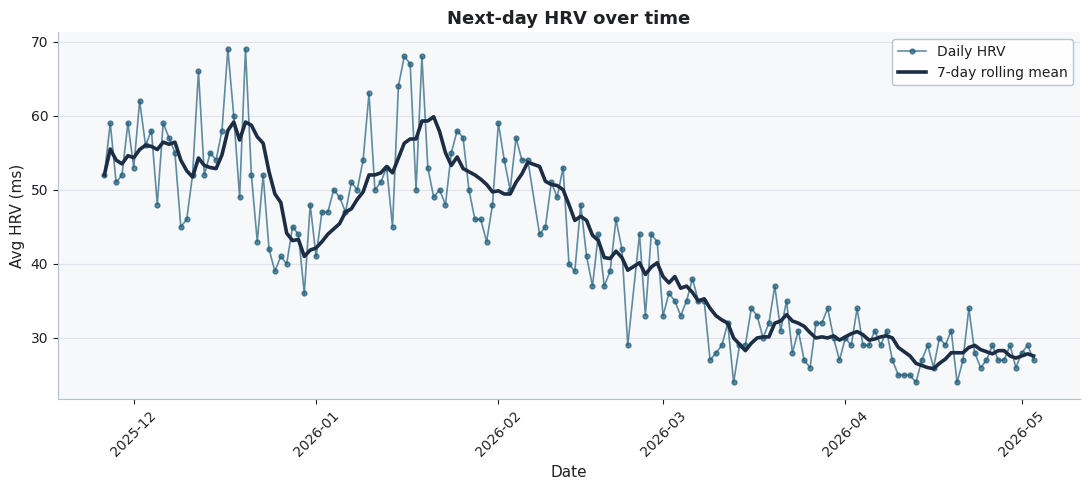

In [80]:
#HRV time series

plt.figure(figsize=(11, 5))
plt.plot(
    model_df["date"],
    model_df[target],
    marker="o",
    linewidth=1.2,
    markersize=3.5,
    color=COLORS["blue"],
    alpha=0.70,
    label="Daily HRV"
)
plt.plot(
    model_df["date"],
    model_df[target].rolling(7, min_periods=1).mean(),
    linewidth=2.6,
    color=COLORS["navy"],
    label="7-day rolling mean"
)
plt.title("Next-day HRV over time")
plt.xlabel("Date")
plt.ylabel("Avg HRV (ms)")
plt.legend()
plt.xticks(rotation=45)
polish_axes()
plt.tight_layout()
save_and_show("hrv_time_series.png")

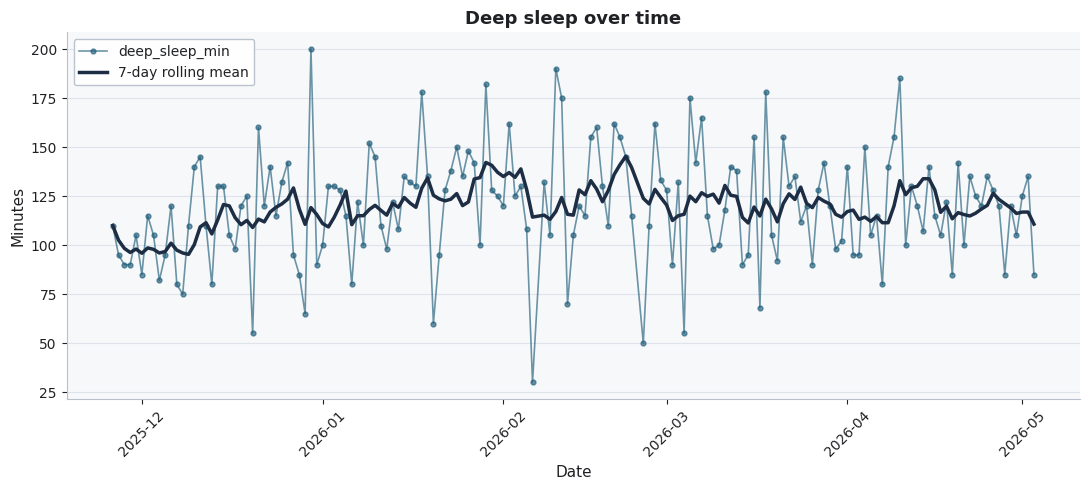

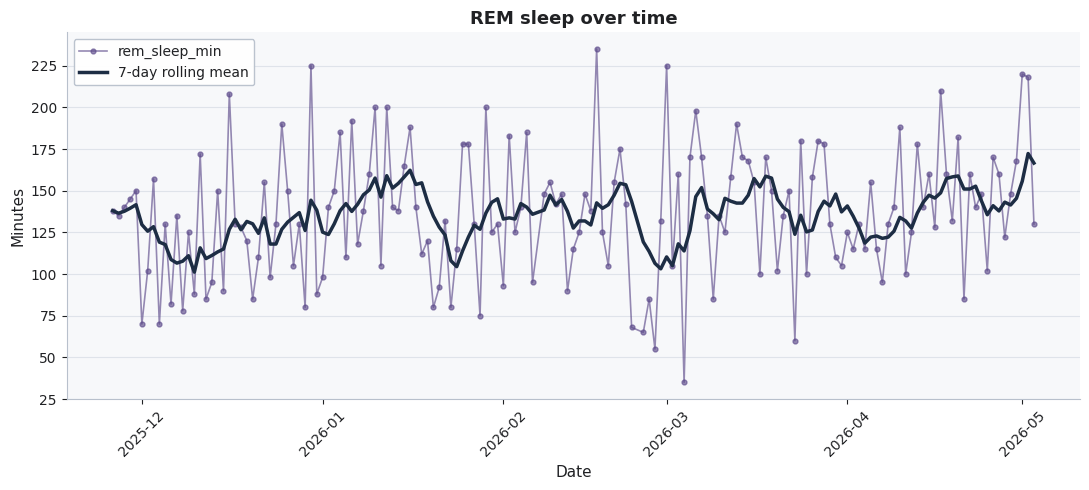

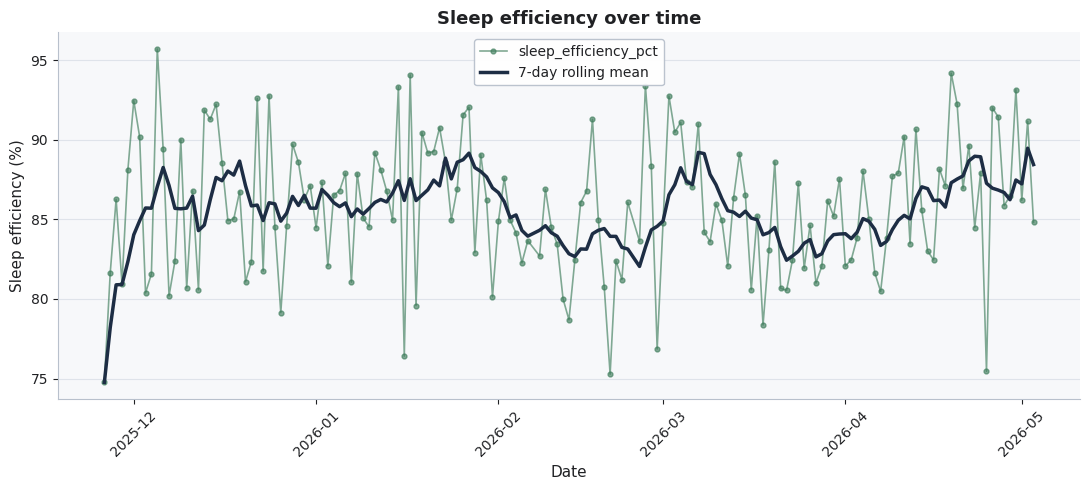

In [81]:
for col, title, ylabel in [
    ("deep_sleep_min", "Deep sleep over time", "Minutes"),
    ("rem_sleep_min", "REM sleep over time", "Minutes"),
    ("sleep_efficiency_pct", "Sleep efficiency over time", "Sleep efficiency (%)")
]:
    base_color = FEATURE_COLORS.get(col, COLORS["blue"])
    plt.figure(figsize=(11, 5))
    plt.plot(
        model_df["date"],
        model_df[col],
        marker="o",
        linewidth=1.2,
        markersize=3.5,
        color=base_color,
        alpha=0.65,
        label=col
    )
    plt.plot(
        model_df["date"],
        model_df[col].rolling(7, min_periods=1).mean(),
        linewidth=2.5,
        color=COLORS["navy"],
        label="7-day rolling mean"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.xticks(rotation=45)
    polish_axes()
    plt.tight_layout()
    save_and_show(f"{col}_time_series.png")

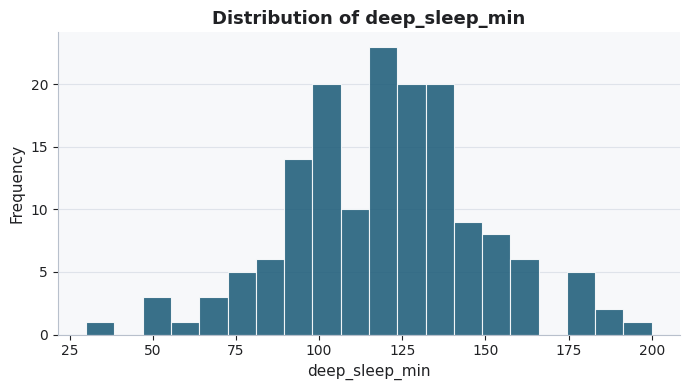

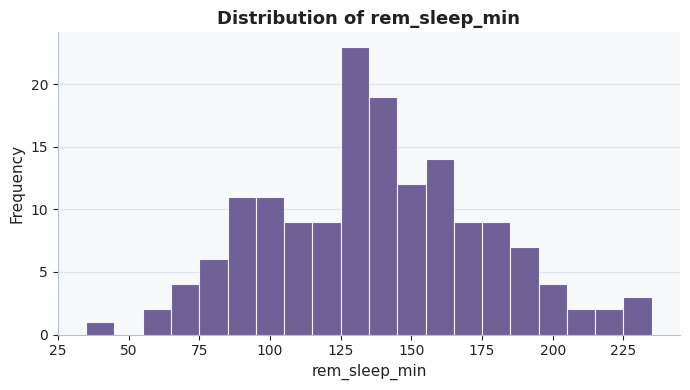

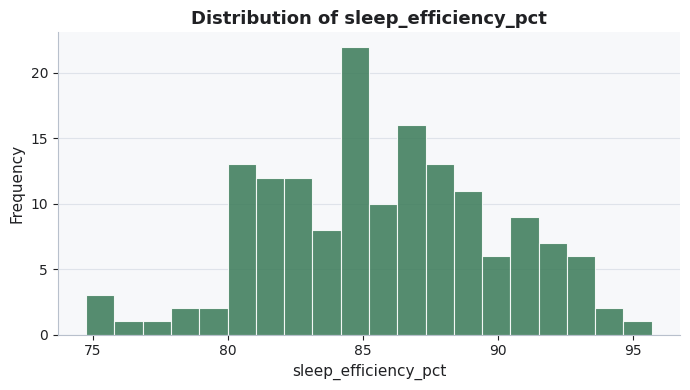

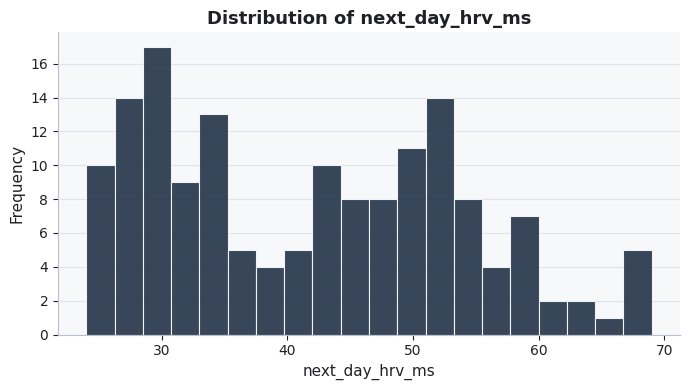

In [82]:
for col in core_features + [target]:
    base_color = FEATURE_COLORS.get(col, COLORS["blue"])
    plt.figure(figsize=(7,4))
    plt.hist(
        model_df[col].dropna(),
        bins=20,
        color=base_color,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.88
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    polish_axes()
    plt.tight_layout()
    save_and_show(f"hist_{col}.png")

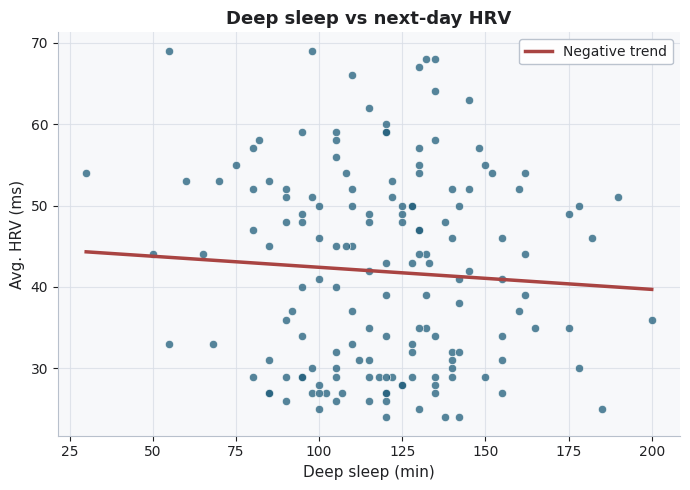

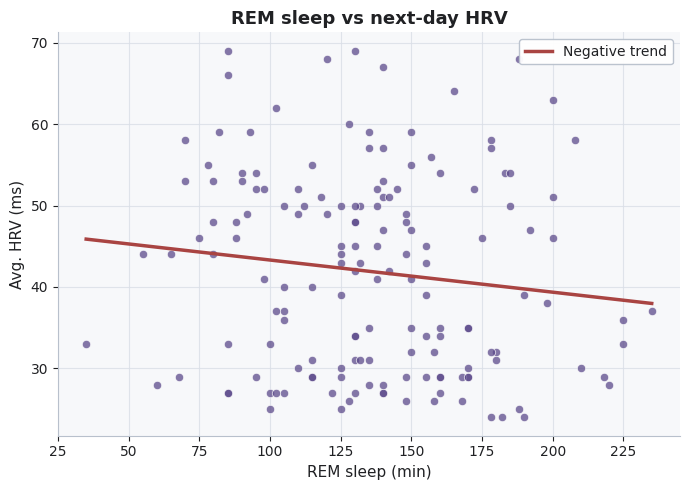

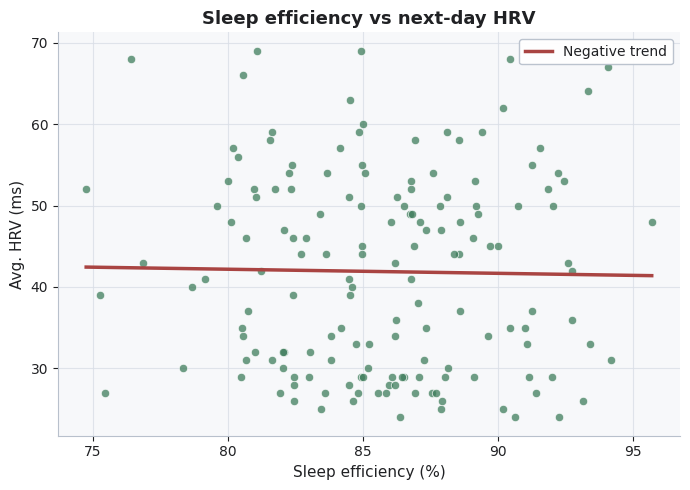

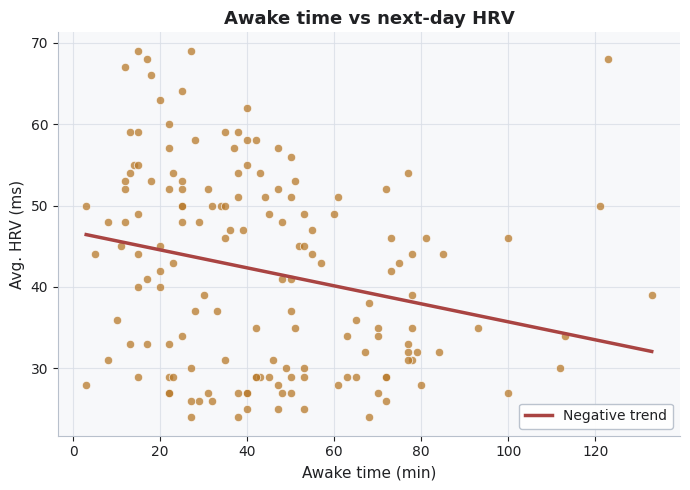

In [83]:
def scatter_with_trend(df, x, y, title, xlabel, ylabel, filename):
    clean = df[[x, y]].dropna()
    point_color = FEATURE_COLORS.get(x, COLORS["blue"])
    plt.figure(figsize=(7,5))
    plt.scatter(
        clean[x],
        clean[y],
        alpha=0.75,
        color=point_color,
        edgecolor="white",
        linewidth=0.6
    )

    if len(clean)>1:
        slope, intercept = np.polyfit(clean[x], clean[y], 1)
        xs = np.linspace(clean[x].min(), clean[x].max(), 100)

        trend_color = COLORS["blue"] if slope >= 0 else COLORS["red"]

        plt.plot(
            xs,
            slope*xs + intercept,
            linewidth=2.5,
            color=trend_color,
            label="Positive trend" if slope >= 0 else "Negative trend"
        )
        plt.legend()

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    polish_axes(grid_axis="both")
    plt.tight_layout()
    save_and_show(filename)

scatter_with_trend(
    model_df,
    "deep_sleep_min",
    target,
    "Deep sleep vs next-day HRV",
    "Deep sleep (min)",
    "Avg. HRV (ms)",
    "scatter_deep_hrv.png"
)
scatter_with_trend(
    model_df,
    "rem_sleep_min",
    target,
    "REM sleep vs next-day HRV",
    "REM sleep (min)",
    "Avg. HRV (ms)",
    "scatter_rem_hrv.png"
)
scatter_with_trend(
    model_df,
    "sleep_efficiency_pct",
    target,
    "Sleep efficiency vs next-day HRV",
    "Sleep efficiency (%)",
    "Avg. HRV (ms)",
    "scatter_efficiency_hrv.png"
)

scatter_with_trend(
    model_df,
    "awake_min",
    target,
    "Awake time vs next-day HRV",
    "Awake time (min)",
    "Avg. HRV (ms)",
    "scatter_awake_hrv.png"
)

,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,time_asleep_min,awake_min,deep_sleep_pct_of_asleep,rem_sleep_pct_of_asleep,awake_pct_of_time_in_bed,steps_prev_day,calories_prev_day,next_day_hrv_ms
deep_sleep_min,1.000,0.446,-0.072,0.753,0.497,0.626,-0.072,0.318,-0.061,0.009,-0.065
rem_sleep_min,0.446,1.000,0.088,0.557,0.264,0.028,0.729,0.139,0.015,-0.006,-0.127
sleep_efficiency_pct,-0.072,0.088,1.000,0.201,-0.536,-0.347,-0.073,-0.595,-0.018,-0.014,-0.018
time_asleep_min,0.753,0.557,0.201,1.000,0.355,-0.027,-0.137,0.105,-0.019,0.070,0.003
awake_min,0.497,0.264,-0.536,0.355,1.000,0.339,0.036,0.956,0.041,0.027,-0.240
deep_sleep_pct_of_asleep,0.626,0.028,-0.347,-0.027,0.339,1.000,0.057,0.365,-0.113,-0.106,-0.104
rem_sleep_pct_of_asleep,-0.072,0.729,-0.073,-0.137,0.036,0.057,1.000,0.085,0.020,-0.088,-0.117
awake_pct_of_time_in_bed,0.318,0.139,-0.595,0.105,0.956,0.365,0.085,1.000,0.036,-0.001,-0.290
steps_prev_day,-0.061,0.015,-0.018,-0.019,0.041,-0.113,0.020,0.036,1.000,0.634,-0.051
calories_prev_day,0.009,-0.006,-0.014,0.070,0.027,-0.106,-0.088,-0.001,0.634,1.000,0.210


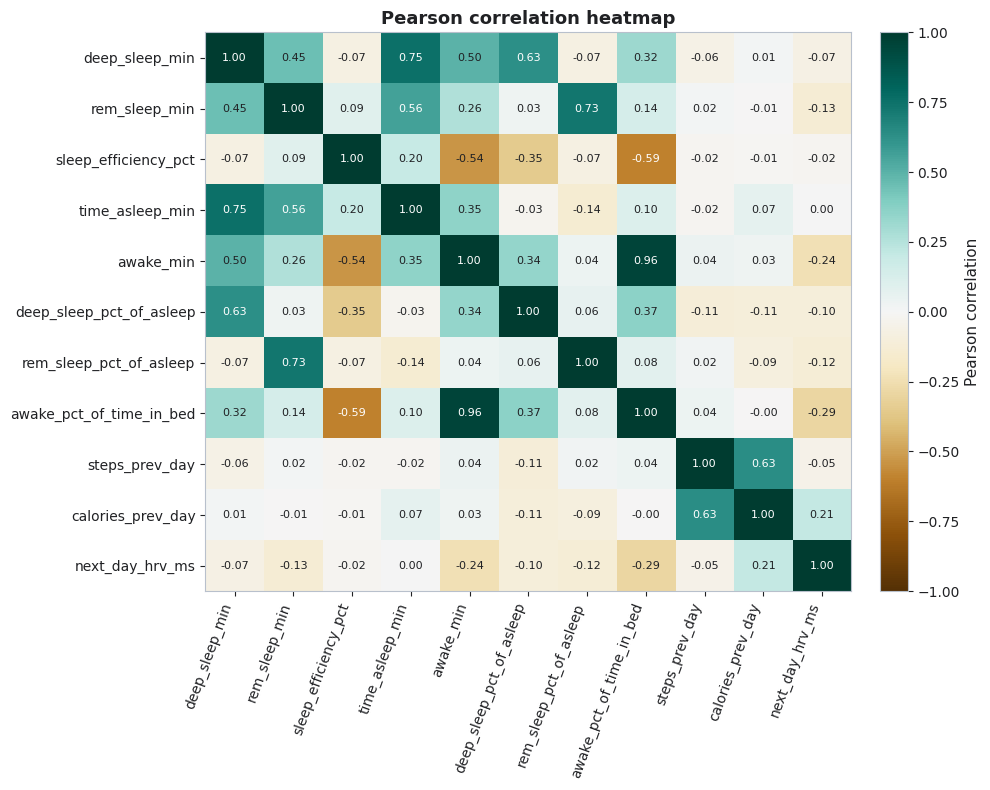

In [84]:
corr_features = [
    "deep_sleep_min",
    "rem_sleep_min",
    "sleep_efficiency_pct",
    "time_asleep_min",
    "awake_min",
    "deep_sleep_pct_of_asleep",
    "rem_sleep_pct_of_asleep",
    "awake_pct_of_time_in_bed",
    "steps_prev_day",
    "calories_prev_day",
    target
]

corr=model_df[corr_features].corr(method="pearson")

display(corr.round(3))

plt.figure(figsize=(10, 8))

im=plt.imshow(
    corr,
    aspect="auto",
    cmap="BrBG",
    vmin=-1,
    vmax=1
)

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=70, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Pearson correlation heatmap")
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        text_color = "white" if abs(value) > 0.55 else COLORS["dark"]
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=text_color
        )
plt.tight_layout()
save_and_show("correlation_heatmap.png")

,feature,pearson_correlation_with_next_day_hrv
0,awake_pct_of_time_in_bed,-0.289665
1,awake_min,-0.240067
2,calories_prev_day,0.210334
3,rem_sleep_min,-0.126519
4,rem_sleep_pct_of_asleep,-0.117195
5,deep_sleep_pct_of_asleep,-0.103966
6,deep_sleep_min,-0.065054
7,steps_prev_day,-0.050678
8,sleep_efficiency_pct,-0.017608
9,time_asleep_min,0.003500


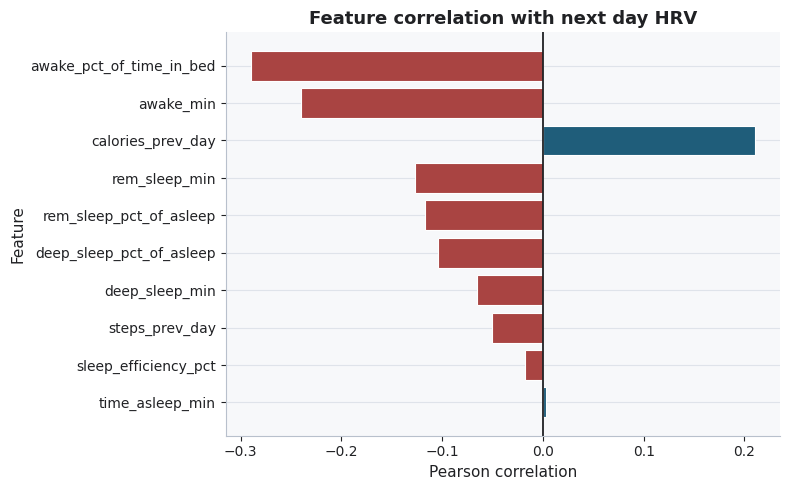

In [85]:
hrv_corr = corr[target].drop(target).sort_values(
    key=lambda s: s.abs(),
    ascending=False
)
correlation_ranking = hrv_corr.reset_index()
correlation_ranking.columns = [
    "feature",
    "pearson_correlation_with_next_day_hrv"
]
display(correlation_ranking)
plt.figure(figsize=(8,5))
values = correlation_ranking["pearson_correlation_with_next_day_hrv"]
plt.barh(
    correlation_ranking["feature"],
    values,
    color=signed_colors(values),
    edgecolor="white",
    linewidth=0.8
)
plt.axvline(0, linewidth=1.3, color=COLORS["dark"])
plt.title("Feature correlation with next day HRV")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show("correlation_ranking_hrv.png")

,feature,pearson_correlation_with_next_day_hrv
3,rem_sleep_min,-0.126519
6,deep_sleep_min,-0.065054
8,sleep_efficiency_pct,-0.017608


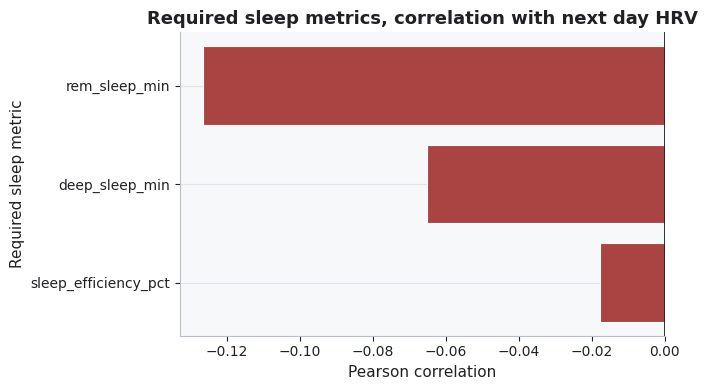

In [86]:
required_sleep_ranking = correlation_ranking[
    correlation_ranking["feature"].isin(core_features)
].copy()

display(required_sleep_ranking)
plt.figure(figsize=(7,4))
values = required_sleep_ranking["pearson_correlation_with_next_day_hrv"]
plt.barh(
    required_sleep_ranking["feature"],
    values,
    color=signed_colors(values),
    edgecolor="white",
    linewidth=0.8
)
plt.axvline(0, linewidth=1.3, color=COLORS["dark"])
plt.title("Required sleep metrics, correlation with next day HRV")
plt.xlabel("Pearson correlation")
plt.ylabel("Required sleep metric")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show("required_sleep_metrics_hrv.png")

In [87]:
print("Interpretation of required sleep metrics:")
for _, row in required_sleep_ranking.iterrows():
    feature = row["feature"]
    corr_value = row["pearson_correlation_with_next_day_hrv"]
    direction = "positive" if corr_value > 0 else "negative"
    strength = abs(corr_value)

    if strength<0.1:
        strength_text= "very weak"
    elif strength< 0.3:
        strength_text = "weak"
    elif strength< 0.5:
        strength_text = "moderate"
    else:
        strength_text = "strong"

    print(f"{feature}: r = {corr_value:.3f}, {strength_text} {direction} association with next day HRV.")

Interpretation of required sleep metrics:
rem_sleep_min: r = -0.127, weak negative association with next day HRV.
deep_sleep_min: r = -0.065, very weak negative association with next day HRV.
sleep_efficiency_pct: r = -0.018, very weak negative association with next day HRV.


Clustering data shape: (157, 4)


,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,next_day_hrv_ms
0,110,138,74.755473,52
1,95,135,81.653584,59
2,90,140,86.255924,51
3,90,145,80.956938,52
4,105,150,88.113208,59


,k,inertia,silhouette_score
0,2,331.466517,0.253581
1,3,249.637178,0.266206
2,4,211.510306,0.240389
3,5,181.826572,0.251526
4,6,161.511662,0.241393
5,7,145.415999,0.259705


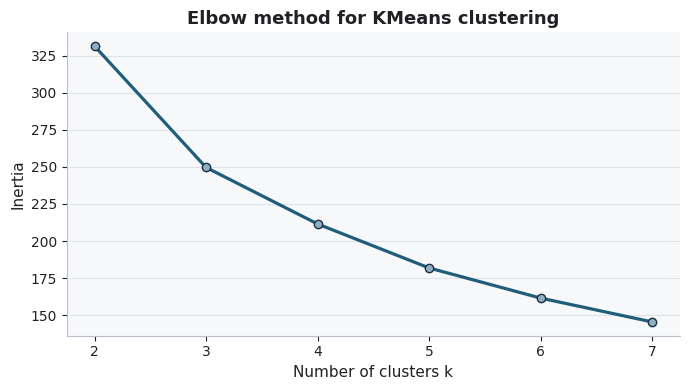

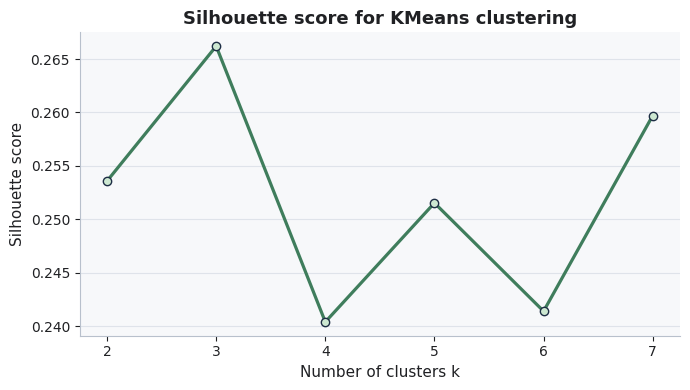

In [88]:
#Prepare data for sleep profile clustering

from sklearn.metrics import silhouette_score

X_cluster = model_df[core_features + [target]].dropna().copy()

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster[core_features])

print("Clustering data shape:", X_cluster.shape)
display(X_cluster.head())

#Elbow method and silhouette score for k selection
cluster_quality_rows=[]

possible_k_values = range(2, min(8, len(X_cluster)))

for k_test in possible_k_values:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)

    cluster_quality_rows.append({
        "k": k_test,
        "inertia": km.inertia_,
        "silhouette_score": silhouette_score(X_scaled, labels)
    })

cluster_quality = pd.DataFrame(cluster_quality_rows)
display(cluster_quality)

plt.figure(figsize=(7,4))

plt.plot(
    cluster_quality["k"],
    cluster_quality["inertia"],
    marker="o",
    linewidth=2.3,
    color=COLORS["blue"],
    markerfacecolor=COLORS["light_blue"],
    markeredgecolor=COLORS["navy"]
)

plt.title("Elbow method for KMeans clustering")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
polish_axes()
plt.tight_layout()
save_and_show("kmeans_elbow.png")

plt.figure(figsize=(7,4))

plt.plot(
    cluster_quality["k"],
    cluster_quality["silhouette_score"],
    marker="o",
    linewidth=2.3,
    color=COLORS["green"],
    markerfacecolor="#CDE8D1",
    markeredgecolor=COLORS["navy"]
)
plt.title("Silhouette score for KMeans clustering")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
polish_axes()
plt.tight_layout()
save_and_show("kmeans_silhouette.png")

deep_sleep_min                         rem_sleep_min                          \
                                mean median        std count          mean median        std count   
sleep_profile_cluster                                                                                
0                          93.900000   95.0  23.235485    50    100.660000   99.0  25.211441    50   
1                         130.381818  130.0  22.345346    55    134.781818  135.0  25.382037    55   
2                         132.365385  130.0  24.239838    52    171.057692  170.0  28.703633    52   

                      sleep_efficiency_pct                            next_day_hrv_ms                          
                                      mean     median       std count            mean median        std count  
sleep_profile_cluster                                                                                          
0                                87.043911  86.778741  3.696674    50       42.720000   44.5  12.232509    50  
1                                81.761615  82.063492  2.680734    55       41.854545   42.0  11.298014    55  
2                                88.726111  87.978658  2.541241    52       41.134615   38.5  12.926684    52

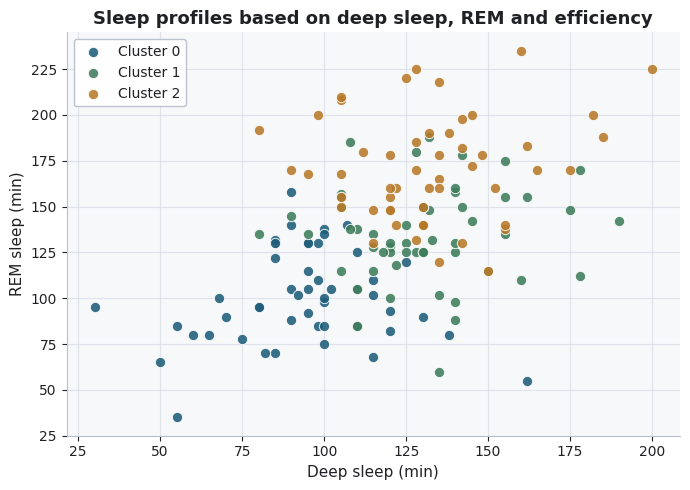

In [89]:
k=3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
model_df_clustered = model_df.loc[X_cluster.index].copy()
model_df_clustered["sleep_profile_cluster"] = clusters
cluster_summary = model_df_clustered.groupby("sleep_profile_cluster")[
    core_features + [target]
].agg(["mean", "median", "std","count"])

display(cluster_summary)
plt.figure(figsize=(7,5))
for cluster_id in sorted(model_df_clustered["sleep_profile_cluster"].unique()):
    tmp = model_df_clustered[
        model_df_clustered["sleep_profile_cluster"] == cluster_id
    ]
    plt.scatter(
        tmp["deep_sleep_min"],
        tmp["rem_sleep_min"],
        label=f"Cluster {cluster_id}",
        alpha=0.88,
        color=CLUSTER_COLORS[cluster_id % len(CLUSTER_COLORS)],
        edgecolor="white",
        linewidth=0.7,
        s=55
    )
plt.title("Sleep profiles based on deep sleep, REM and efficiency")
plt.xlabel("Deep sleep (min)")
plt.ylabel("REM sleep (min)")
plt.legend()
polish_axes(grid_axis="both")
plt.tight_layout()
save_and_show("sleep_profile_clusters.png")

,next_day_hrv_ms
sleep_profile_cluster,
0,42.720000
1,41.854545
2,41.134615


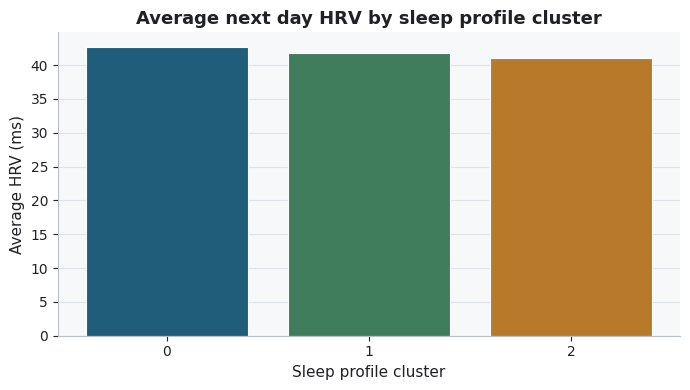

In [90]:
cluster_hrv = model_df_clustered.groupby("sleep_profile_cluster")[target].mean()
display(cluster_hrv)
plt.figure(figsize=(7,4))
plt.bar(
    cluster_hrv.index.astype(str),
    cluster_hrv.values,
    color=[CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i in range(len(cluster_hrv))],
    edgecolor="white",
    linewidth=0.8
)

plt.title("Average next day HRV by sleep profile cluster")
plt.xlabel("Sleep profile cluster")
plt.ylabel("Average HRV (ms)")
plt.xticks(rotation=0)
polish_axes()
plt.tight_layout()
save_and_show("cluster_average_hrv.png")

In [91]:
model_df.to_csv("sleep_hrv_model_ready_cda.csv", index=False)
model_df_clustered.to_csv("sleep_hrv_model_ready_with_clusters_cda.csv", index=False)
quality_summary.to_csv("data_quality_summary_cda.csv", index=False)
iqr_report.to_csv("iqr_outlier_report_cda.csv", index=False)
z_report.to_csv("zscore_outlier_report_cda.csv", index=False)
correlation_ranking.to_csv("correlation_ranking_cda.csv", index=False)
print("Saved files:")
print("sleep_hrv_model_ready_cda.csv")
print("sleep_hrv_model_ready_with_clusters_cda.csv")
print("data_quality_summary_cda.csv")
print("iqr_outlier_report_cda.csv")
print("zscore_outlier_report_cda.csv")
print("correlation_ranking_cda.csv")
print(f"Figures saved in folder: {FIG_DIR}")

Saved files:
sleep_hrv_model_ready_cda.csv
sleep_hrv_model_ready_with_clusters_cda.csv
data_quality_summary_cda.csv
iqr_outlier_report_cda.csv
zscore_outlier_report_cda.csv
correlation_ranking_cda.csv
Figures saved in folder: figures_cda


In [92]:
best_feature = correlation_ranking.iloc[0]["feature"]
best_corr = correlation_ranking.iloc[0]["pearson_correlation_with_next_day_hrv"]
print(f"The strongest bivariate association with next-day HRV was observed for: {best_feature}.")
print(f"Pearson correlation: r = {best_corr:.3f}")
print()
print("Among the required sleep inputs only:")
display(required_sleep_ranking)

print()

The strongest bivariate association with next-day HRV was observed for: awake_pct_of_time_in_bed.
Pearson correlation: r = -0.290

Among the required sleep inputs only:


,feature,pearson_correlation_with_next_day_hrv
3,rem_sleep_min,-0.126519
6,deep_sleep_min,-0.065054
8,sleep_efficiency_pct,-0.017608


# **MLPR**

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
from sklearn.inspection import permutation_importance
FIG_DIR_MLPR = Path("figures_mlpr")
FIG_DIR_MLPR.mkdir(exist_ok=True)

def save_and_show_mlpr(filename):
    plt.savefig(FIG_DIR_MLPR / filename, dpi=300, bbox_inches="tight")
    plt.show()
try:
    model_df
    print("Using model_df")
except NameError:
    print("model_df not found")
    model_df = pd.read_csv("sleep_hrv_model_ready_cda.csv")
model_df["date"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values("date").reset_index(drop=True)
display(model_df.head())
print(model_df.shape)

Using model_df


,date,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,next_day_hrv_ms,steps_prev_day,calories_prev_day,time_asleep_min,awake_min,light_sleep_min,deep_sleep_pct_of_asleep,rem_sleep_pct_of_asleep,awake_pct_of_time_in_bed,sleep_records,avg_heart_rate_bpm,avg_spo2_pct
0,2025-11-26,110,138,74.755473,52,5180,1097,428,72,180,25.700935,32.242991,12.575687,1,70,96
1,2025-11-27,95,135,81.653584,59,5186,1613,345,15,115,27.536232,39.130435,3.550156,1,67,95
2,2025-11-28,90,140,86.255924,51,2774,1592,455,50,225,19.780220,30.769231,9.478673,1,68,96
3,2025-11-29,90,145,80.956938,52,4858,1598,423,12,188,21.276596,34.278960,2.296651,1,67,96
4,2025-11-30,105,150,88.113208,59,3478,1560,467,13,212,22.483940,32.119914,2.452830,1,67,96


(157, 16)


In [94]:
target = "next_day_hrv_ms"
required_features = [
    "deep_sleep_min",
    "rem_sleep_min",
    "sleep_efficiency_pct"
]
extracted_features = [
    "time_asleep_min",
    "awake_min",
    "deep_sleep_pct_of_asleep",
    "rem_sleep_pct_of_asleep",
    "awake_pct_of_time_in_bed"
]

available_extracted_features = [
    col for col in extracted_features if col in model_df.columns
]
activity_features = [
    col for col in ["steps_prev_day", "calories_prev_day"] if col in model_df.columns
]
all_candidate_features = required_features + available_extracted_features + activity_features
analysis_df = model_df[["date"] + all_candidate_features + [target]].copy()
analysis_df = analysis_df.dropna(subset=required_features + [target]).reset_index(drop=True)
print("MLPR modeling dataset shape:", analysis_df.shape)
print("Date range:", analysis_df["date"].min().date(), "to", analysis_df["date"].max().date())
display(analysis_df.head())
display(analysis_df[required_features + [target]].describe().T)

MLPR modeling dataset shape: (157, 12)
Date range: 2025-11-26 to 2026-05-03


,date,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,time_asleep_min,awake_min,deep_sleep_pct_of_asleep,rem_sleep_pct_of_asleep,awake_pct_of_time_in_bed,steps_prev_day,calories_prev_day,next_day_hrv_ms
0,2025-11-26,110,138,74.755473,428,72,25.700935,32.242991,12.575687,5180,1097,52
1,2025-11-27,95,135,81.653584,345,15,27.536232,39.130435,3.550156,5186,1613,59
2,2025-11-28,90,140,86.255924,455,50,19.780220,30.769231,9.478673,2774,1592,51
3,2025-11-29,90,145,80.956938,423,12,21.276596,34.278960,2.296651,4858,1598,52
4,2025-11-30,105,150,88.113208,467,13,22.483940,32.119914,2.452830,3478,1560,59


,count,mean,std,min,25%,50%,75%,max
deep_sleep_min,157.0,119.420382,29.008206,30.000000,100.00000,120.000000,135.000000,200.000000
rem_sleep_min,157.0,135.929936,38.762114,35.000000,105.00000,135.000000,160.000000,235.000000
sleep_efficiency_pct,157.0,85.750587,4.241283,74.755473,82.44225,85.972851,88.582677,95.706806
next_day_hrv_ms,157.0,41.891720,12.092369,24.000000,30.00000,42.000000,51.000000,69.000000


In [95]:
#Pattern representation, feature definition and temporal split
required_features = [
    "deep_sleep_min",
    "rem_sleep_min",
    "sleep_efficiency_pct"
]
target = "next_day_hrv_ms"
#only for exploratory feature selection, interpretation
extra_features = [
    "time_asleep_min",
    "awake_min",
    "light_sleep_min",
    "deep_sleep_pct_of_asleep",
    "rem_sleep_pct_of_asleep",
    "awake_pct_of_time_in_bed",
    "steps_prev_day",
    "calories_prev_day",
    "avg_heart_rate_bpm",
    "avg_spo2_pct"
]
all_candidate_features = required_features + [
    col for col in extra_features if col in model_df.columns
]
analysis_df = model_df[["date"] + all_candidate_features + [target]].copy()
analysis_df["date"] = pd.to_datetime(analysis_df["date"], errors="coerce")
for col in all_candidate_features + [target]:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df = analysis_df.dropna(subset=["date"] + required_features + [target])
analysis_df = analysis_df.sort_values("date").reset_index(drop=True)
print("Analysis dataset shape:", analysis_df.shape)
print("Date range:", analysis_df["date"].min().date(), "to", analysis_df["date"].max().date())

display(analysis_df.head())

#matrix X and target y
X=analysis_df[required_features].copy()
y = analysis_df[target].copy()
dates = analysis_df["date"].copy()

#temporal split because this is daily wearable time series data
n = len(analysis_df)

train_end = int(0.60 * n)
val_end = int(0.80 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
dates_train = dates.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
dates_val = dates.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
dates_test = dates.iloc[val_end:]

print("Train:", X_train.shape, dates_train.min().date(), "to", dates_train.max().date())
print("Validation:", X_val.shape, dates_val.min().date(), "to", dates_val.max().date())
print("Test:", X_test.shape, dates_test.min().date(), "to", dates_test.max().date())

split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(X_train),
        "start_date": dates_train.min(),
        "end_date": dates_train.max()
    },
    {
        "split": "validation",
        "rows": len(X_val),
        "start_date": dates_val.min(),
        "end_date": dates_val.max()
    },
    {
        "split": "test",
        "rows": len(X_test),
        "start_date": dates_test.min(),
        "end_date": dates_test.max()
    }
])
display(split_summary)

Analysis dataset shape: (157, 15)
Date range: 2025-11-26 to 2026-05-03


,date,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct,time_asleep_min,awake_min,light_sleep_min,deep_sleep_pct_of_asleep,rem_sleep_pct_of_asleep,awake_pct_of_time_in_bed,steps_prev_day,calories_prev_day,avg_heart_rate_bpm,avg_spo2_pct,next_day_hrv_ms
0,2025-11-26,110,138,74.755473,428,72,180,25.700935,32.242991,12.575687,5180,1097,70,96,52
1,2025-11-27,95,135,81.653584,345,15,115,27.536232,39.130435,3.550156,5186,1613,67,95,59
2,2025-11-28,90,140,86.255924,455,50,225,19.780220,30.769231,9.478673,2774,1592,68,96,51
3,2025-11-29,90,145,80.956938,423,12,188,21.276596,34.278960,2.296651,4858,1598,67,96,52
4,2025-11-30,105,150,88.113208,467,13,212,22.483940,32.119914,2.452830,3478,1560,67,96,59


Train: (94, 3) 2025-11-26 to 2026-03-01
Validation: (31, 3) 2026-03-02 to 2026-04-01
Test: (32, 3) 2026-04-02 to 2026-05-03


,split,rows,start_date,end_date
0,train,94,2025-11-26,2026-03-01
1,validation,31,2026-03-02,2026-04-01
2,test,32,2026-04-02,2026-05-03


In [96]:
#feature extraction and temporal split
required_features = [
    "deep_sleep_min",
    "rem_sleep_min",
    "sleep_efficiency_pct"
]

target="next_day_hrv_ms"
extra_features = [
    "time_asleep_min",
    "awake_min",
    "light_sleep_min",
    "deep_sleep_pct_of_asleep",
    "rem_sleep_pct_of_asleep",
    "awake_pct_of_time_in_bed",
    "steps_prev_day",
    "calories_prev_day",
    "avg_heart_rate_bpm",
    "avg_spo2_pct"
]

all_candidate_features = required_features +[
    col for col in extra_features if col in model_df.columns
]
analysis_df= model_df[["date"] + all_candidate_features + [target]].copy()

analysis_df["date"] = pd.to_datetime(analysis_df["date"], errors="coerce")

for col in all_candidate_features + [target]:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df = analysis_df.dropna(subset=["date"] + required_features + [target])
analysis_df = analysis_df.sort_values("date").reset_index(drop=True)

X = analysis_df[required_features].copy()
y = analysis_df[target].copy()
dates = analysis_df["date"].copy()

n=len(analysis_df)

train_end = int(0.60*n)
val_end = int(0.80*n)
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
dates_train = dates.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
dates_val = dates.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
dates_test = dates.iloc[val_end:]

print("Analysis dataset shape", analysis_df.shape)
print("Train", X_train.shape, dates_train.min().date(), "to", dates_train.max().date())
print("Validation", X_val.shape, dates_val.min().date(), "to", dates_val.max().date())
print("Test", X_test.shape, dates_test.min().date(), "to", dates_test.max().date())

split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(X_train),
        "start_date": dates_train.min(),
        "end_date": dates_train.max()
    },
    {
        "split": "validation",
        "rows": len(X_val),
        "start_date": dates_val.min(),
        "end_date": dates_val.max()
    },
    {
        "split": "test",
        "rows": len(X_test),
        "start_date": dates_test.min(),
        "end_date": dates_test.max()
    }
])
display(split_summary)

Analysis dataset shape (157, 15)
Train (94, 3) 2025-11-26 to 2026-03-01
Validation (31, 3) 2026-03-02 to 2026-04-01
Test (32, 3) 2026-04-02 to 2026-05-03


,split,rows,start_date,end_date
0,train,94,2025-11-26,2026-03-01
1,validation,31,2026-03-02,2026-04-01
2,test,32,2026-04-02,2026-05-03


,feature,pearson_correlation_with_hrv
0,avg_heart_rate_bpm,-0.922618
1,awake_pct_of_time_in_bed,-0.289665
2,avg_spo2_pct,0.286290
3,awake_min,-0.240067
4,calories_prev_day,0.210334
5,rem_sleep_min,-0.126519
6,rem_sleep_pct_of_asleep,-0.117195
7,light_sleep_min,0.109133
8,deep_sleep_pct_of_asleep,-0.103966
9,deep_sleep_min,-0.065054


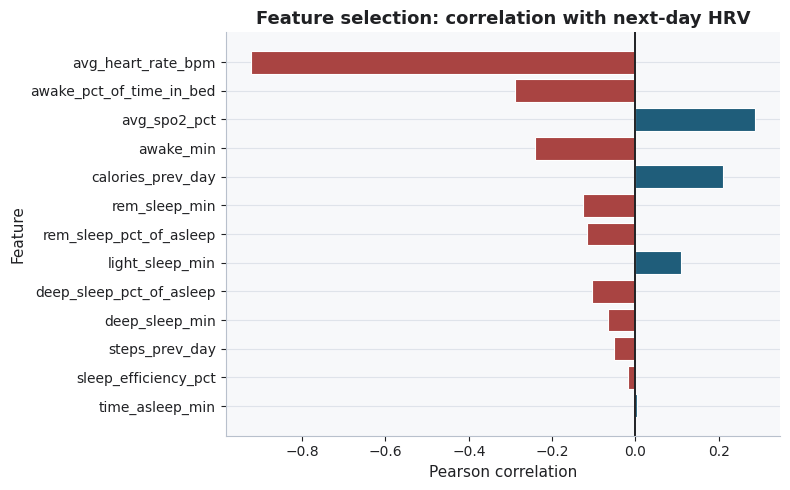

In [97]:
#feature selection by correlation

feature_corr = analysis_df[all_candidate_features + [target]].corr(method="pearson")[target]
feature_corr = feature_corr.drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
feature_selection_table = feature_corr.reset_index()
feature_selection_table.columns = ["feature", "pearson_correlation_with_hrv"]
display(feature_selection_table)
plt.figure(figsize=(8,5))

values = feature_selection_table["pearson_correlation_with_hrv"]
plt.barh(
    feature_selection_table["feature"],
    values,
    color=signed_colors(values),
    edgecolor="white",
    linewidth=0.8
)
plt.axvline(0, linewidth=1.4, color=COLORS["dark"])
plt.title("Feature selection: correlation with next-day HRV")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("feature_selection_correlation.png")

In [98]:
#temporal holdout split

X = analysis_df[required_features].copy()
y = analysis_df[target].copy()
dates = analysis_df["date"].copy()

n = len(analysis_df)

train_end = int(0.60 * n)
val_end = int(0.80 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
dates_train = dates.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
dates_val = dates.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]
dates_test = dates.iloc[val_end:]

print("Train:", X_train.shape, dates_train.min().date(), "to", dates_train.max().date())
print("Validation:", X_val.shape, dates_val.min().date(), "to", dates_val.max().date())
print("Test:", X_test.shape, dates_test.min().date(), "to", dates_test.max().date())

Train: (94, 3) 2025-11-26 to 2026-03-01
Validation: (31, 3) 2026-03-02 to 2026-04-01
Test: (32, 3) 2026-04-02 to 2026-05-03


In [99]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [100]:
#candidate regression models

candidate_models = {
    "Baseline mean": DummyRegressor(strategy="mean"),
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "KNN Regression k=5": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5, weights="distance"))
    ]),
    "Decision Tree Regression": DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    )
}
validation_rows = []
for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    metrics = regression_metrics(y_val, val_pred)

    validation_rows.append({
        "model": model_name,
        "validation_MAE": metrics["MAE"],
        "validation_RMSE": metrics["RMSE"],
        "validation_R2": metrics["R2"]
    })

validation_results=pd.DataFrame(validation_rows).sort_values("validation_RMSE")
display(validation_results)

,model,validation_MAE,validation_RMSE,validation_R2
3,KNN Regression k=5,17.878159,18.518056,-27.766112
0,Baseline mean,18.633837,18.951010,-29.126946
2,Ridge Regression,18.629804,19.013111,-29.324717
1,Linear Regression,18.631217,19.015782,-29.333237
4,Decision Tree Regression,18.835334,19.198843,-29.920073


In [101]:
#small validation tuning

tuned_candidates = {}

#ridge tuning
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    tuned_candidates[f"Ridge alpha={alpha}"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

#KNN tuning
for k in [3, 5, 7, 9, 11, 15]:
    tuned_candidates[f"KNN k={k}"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=k, weights="distance"))
    ])

#Tree tuning
for depth in [2, 3, 4, 5]:
    tuned_candidates[f"Tree depth={depth}"] = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
tuned_candidates["Random Forest"] = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    random_state=42
)

#baseline and linear regression
tuned_candidates["Baseline mean"] = DummyRegressor(strategy="mean")
tuned_candidates["Linear Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
tuning_rows = []
for model_name, model in tuned_candidates.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    metrics = regression_metrics(y_val, val_pred)
    tuning_rows.append({
        "model": model_name,
        "validation_MAE": metrics["MAE"],
        "validation_RMSE": metrics["RMSE"],
        "validation_R2": metrics["R2"]
    })
tuning_results = pd.DataFrame(tuning_rows).sort_values("validation_RMSE").reset_index(drop=True)
display(tuning_results)
best_model_name = tuning_results.iloc[0]["model"]
best_model = tuned_candidates[best_model_name]
print("Best validation model:", best_model_name)

,model,validation_MAE,validation_RMSE,validation_R2
0,KNN k=3,17.734351,18.443080,-27.533648
1,KNN k=5,17.878159,18.518056,-27.766112
2,KNN k=7,18.053218,18.602526,-28.029144
3,KNN k=9,18.254852,18.736644,-28.449235
4,KNN k=11,18.356294,18.836275,-28.763254
5,Ridge alpha=100.0,18.604032,18.944496,-29.106239
6,Baseline mean,18.633837,18.951010,-29.126946
7,Ridge alpha=10.0,18.619951,18.993818,-29.263205
8,Ridge alpha=1.0,18.629804,19.013111,-29.324717
9,Ridge alpha=0.1,18.631072,19.015509,-29.332366


Best validation model: KNN k=3


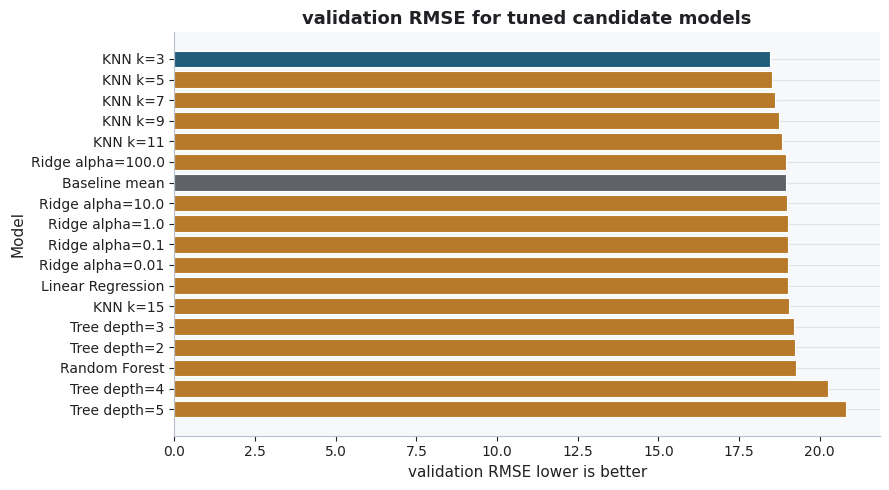

In [102]:
plt.figure(figsize=(9,5))
plt.barh(
    tuning_results["model"],
    tuning_results["validation_RMSE"],
    color=model_metric_colors(tuning_results["model"], tuning_results["validation_RMSE"]),
    edgecolor="white",
    linewidth=0.8
)
plt.title("validation RMSE for tuned candidate models")
plt.xlabel("validation RMSE lower is better")
plt.ylabel("Model")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("validation_tuning_rmse.png")

In [103]:
#refit best model on train and validation
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_model.fit(X_trainval, y_trainval)
test_pred = best_model.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)
test_results = pd.DataFrame([
    {
        "model": best_model_name,
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"]
    }
])
display(test_results)
prediction_results = pd.DataFrame({
    "date": dates_test.values,
    "actual_hrv": y_test.values,
    "predicted_hrv": test_pred,
    "residual": y_test.values - test_pred
})
display(prediction_results.head())

,model,test_MAE,test_RMSE,test_R2
0,KNN k=3,18.577522,19.446601,-62.733769


,date,actual_hrv,predicted_hrv,residual
0,2026-04-02,29,47.148033,-18.148033
1,2026-04-03,34,60.445744,-26.445744
2,2026-04-04,29,54.085341,-25.085341
3,2026-04-05,29,45.990583,-16.990583
4,2026-04-06,31,43.109598,-12.109598


,date,actual_hrv,predicted_hrv,residual,absolute_error,squared_error
count,32,32.000000,32.000000,32.000000,32.000000,32.000000
mean,2026-04-17 12:00:00,28.062500,46.640022,-18.577522,18.577522,378.170291
min,2026-04-02 00:00:00,24.000000,32.169424,-30.661103,4.169424,17.384098
25%,2026-04-09 18:00:00,26.750000,43.353976,-23.402480,14.645750,214.498448
50%,2026-04-17 12:00:00,28.000000,45.293260,-19.265207,19.265207,371.163535
75%,2026-04-25 06:00:00,29.000000,49.823939,-14.645750,23.402480,547.693308
max,2026-05-03 00:00:00,34.000000,60.445744,-4.169424,30.661103,940.103216
std,NaN,2.474874,5.640878,5.840544,5.840544,210.489392


Largest absolute prediction errors:


,date,actual_hrv,predicted_hrv,residual,absolute_error,squared_error
18,2026-04-20,24,54.661103,-30.661103,30.661103,940.103216
1,2026-04-03,34,60.445744,-26.445744,26.445744,699.377381
5,2026-04-07,29,54.819373,-25.819373,25.819373,666.640029
2,2026-04-04,29,54.085341,-25.085341,25.085341,629.274337
31,2026-05-03,27,51.345506,-24.345506,24.345506,592.703668
21,2026-04-23,28,52.161513,-24.161513,24.161513,583.778705
15,2026-04-17,30,54.046237,-24.046237,24.046237,578.221503
22,2026-04-24,26,49.629864,-23.629864,23.629864,558.370460
26,2026-04-28,27,50.326686,-23.326686,23.326686,544.134257
28,2026-04-30,26,48.558810,-22.558810,22.558810,508.899889


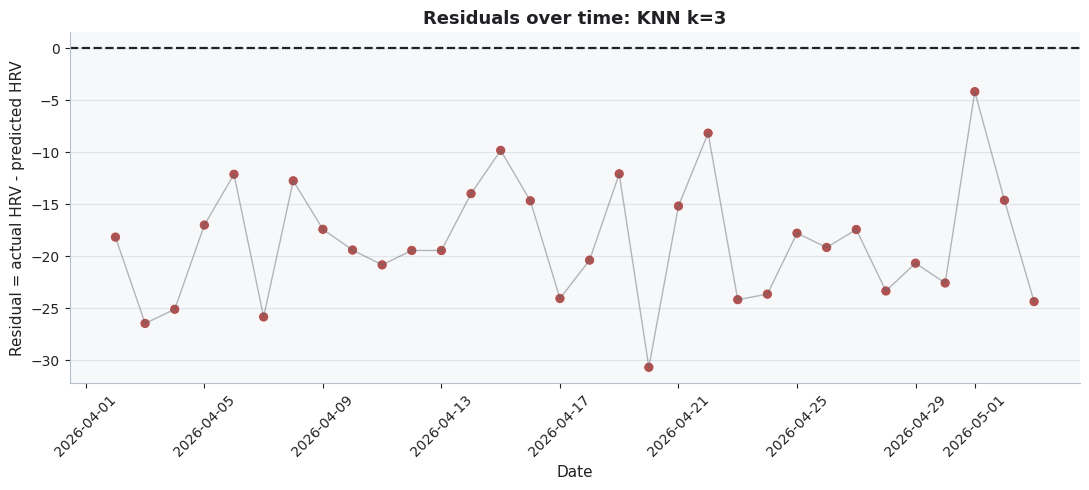

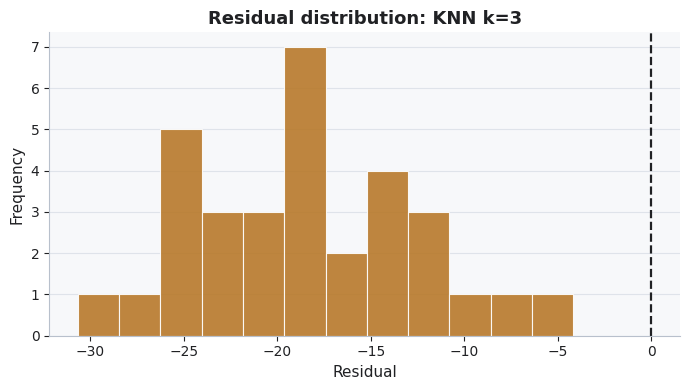

In [104]:
#residual and error analysis
prediction_results["absolute_error"] = prediction_results["residual"].abs()
prediction_results["squared_error"] = prediction_results["residual"]**2
display(prediction_results.describe())
largest_errors = prediction_results.sort_values(
    "absolute_error",
    ascending=False
).head(10)
print("Largest absolute prediction errors:")
display(largest_errors)

residual_colors = [
    COLORS["blue"] if value >=0 else COLORS["red"]
    for value in prediction_results["residual"]
]
plt.figure(figsize=(11,5))
plt.scatter(
    prediction_results["date"],
    prediction_results["residual"],
    color=residual_colors,
    edgecolor="white",
    linewidth=0.7,
    alpha=0.92,
    s=55
)
plt.plot(
    prediction_results["date"],
    prediction_results["residual"],
    color=COLORS["gray"],
    linewidth=1,
    alpha=0.45
)
plt.axhline(0, linestyle="--", linewidth=1.6, color=COLORS["dark"])
plt.title(f"Residuals over time: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Residual = actual HRV - predicted HRV")
plt.xticks(rotation=45)
polish_axes()
plt.tight_layout()
save_and_show_mlpr("residuals_over_time.png")
plt.figure(figsize=(7, 4))
plt.hist(
    prediction_results["residual"],
    bins=12,
    color=COLORS["orange"],
    edgecolor="white",
    linewidth=0.8,
    alpha=0.90
)
plt.axvline(0, linestyle="--", linewidth=1.6, color=COLORS["dark"])
plt.title(f"Residual distribution: {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
polish_axes()
plt.tight_layout()
save_and_show_mlpr("residual_histogram.png")

,model,test_MAE,test_RMSE,test_R2
0,Baseline mean,17.369500,17.539473,-50.846004
1,Ridge Regression,17.448267,17.635084,-51.412786
2,Linear Regression,17.449413,17.636478,-51.421072
3,Random Forest,17.835721,18.127704,-54.381895
4,KNN Regression k=3,17.685834,18.298953,-55.433201
5,Decision Tree Regression,18.227121,19.172013,-60.946624


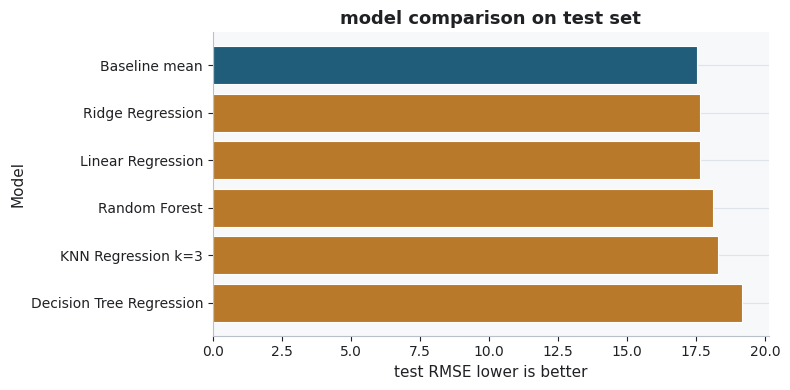

In [105]:
#compare selected final models on test set
final_models = {
    "Baseline mean": DummyRegressor(strategy="mean"),
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "KNN Regression k=3": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5, weights="distance"))
    ]),
    "Decision Tree Regression": DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        random_state=42
    )
}
test_comparison_rows=[]
for model_name, model in final_models.items():
    model.fit(X_trainval, y_trainval)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)

    test_comparison_rows.append({
        "model": model_name,
        "test_MAE": metrics["MAE"],
        "test_RMSE": metrics["RMSE"],
        "test_R2": metrics["R2"]
    })
test_comparison=pd.DataFrame(test_comparison_rows).sort_values("test_RMSE").reset_index(drop=True)
display(test_comparison)
plt.figure(figsize=(8,4))
plt.barh(
    test_comparison["model"],
    test_comparison["test_RMSE"],
    color=model_metric_colors(test_comparison["model"], test_comparison["test_RMSE"]),
    edgecolor="white",
    linewidth=0.8
)
plt.title("model comparison on test set")
plt.xlabel("test RMSE lower is better")
plt.ylabel("Model")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("test_model_comparison_rmse.png")

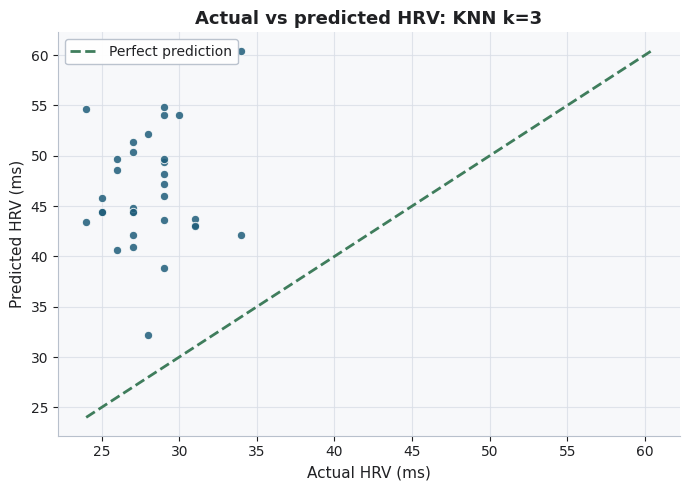

In [106]:
plt.figure(figsize=(7,5))
plt.scatter(
    prediction_results["actual_hrv"],
    prediction_results["predicted_hrv"],
    alpha=0.85,
    color=COLORS["blue"],
    edgecolor="white",
    linewidth=0.7
)
min_val = min(
    prediction_results["actual_hrv"].min(),
    prediction_results["predicted_hrv"].min()
)
max_val = max(
    prediction_results["actual_hrv"].max(),
    prediction_results["predicted_hrv"].max()
)
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color=COLORS["green"],
    label="Perfect prediction"
)
plt.title(f"Actual vs predicted HRV: {best_model_name}")
plt.xlabel("Actual HRV (ms)")
plt.ylabel("Predicted HRV (ms)")
plt.legend()
polish_axes(grid_axis="both")
plt.tight_layout()
save_and_show_mlpr("actual_vs_predicted_hrv.png")

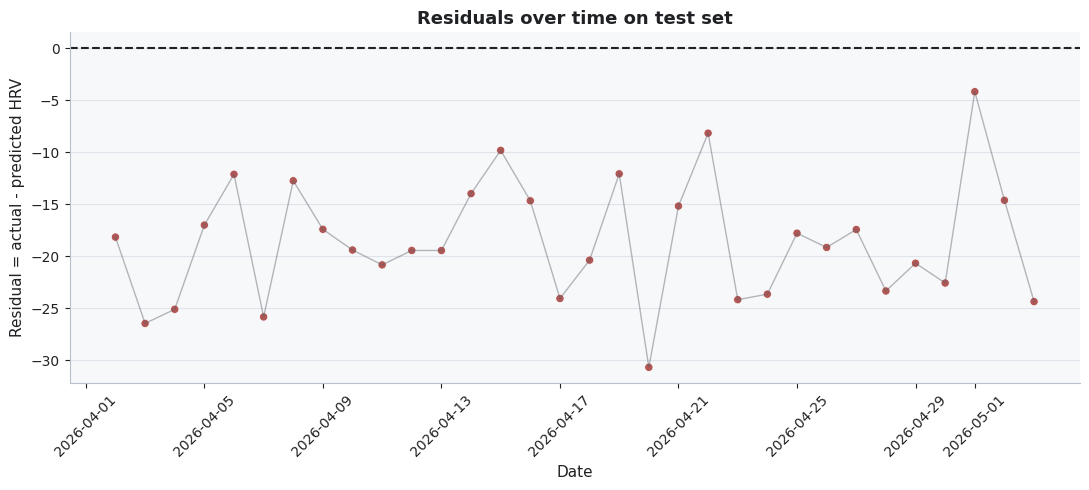

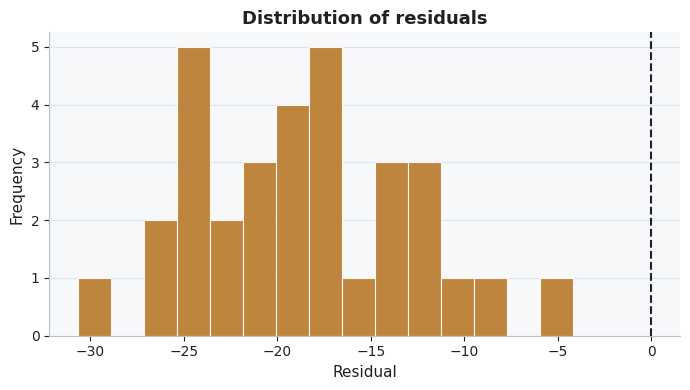

In [107]:
residual_colors = [
    COLORS["blue"] if value >= 0 else COLORS["red"]
    for value in prediction_results["residual"]
]
plt.figure(figsize=(11, 5))
plt.scatter(
    prediction_results["date"],
    prediction_results["residual"],
    color=residual_colors,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9
)
plt.plot(
    prediction_results["date"],
    prediction_results["residual"],
    color=COLORS["gray"],
    linewidth=1,
    alpha=0.45
)
plt.axhline(0, linestyle="--", linewidth=1.5, color=COLORS["dark"])
plt.title("Residuals over time on test set")
plt.xlabel("Date")
plt.ylabel("Residual = actual - predicted HRV")
plt.xticks(rotation=45)
polish_axes()
plt.tight_layout()
save_and_show_mlpr("residuals_over_time.png")

plt.figure(figsize=(7,4))
plt.hist(
    prediction_results["residual"],
    bins=15,
    color=COLORS["orange"],
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9
)
plt.axvline(0, linestyle="--", linewidth=1.5, color=COLORS["dark"])
plt.title("Distribution of residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
polish_axes()
plt.tight_layout()
save_and_show_mlpr("residual_distribution.png")

,feature,standardized_linear_coefficient,absolute_effect_size
2,sleep_efficiency_pct,0.709506,0.709506
0,deep_sleep_min,-0.679863,0.679863
1,rem_sleep_min,-0.406452,0.406452


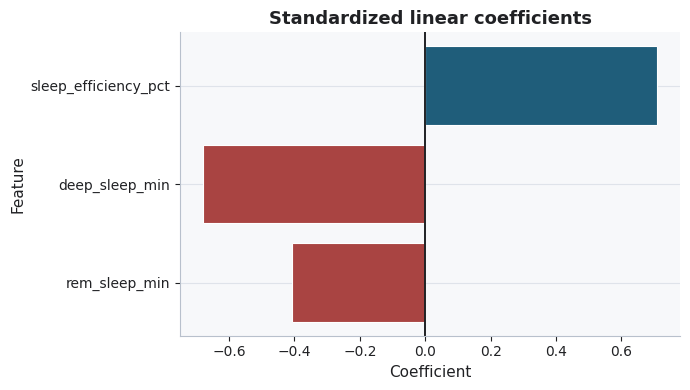

In [108]:
#standardized linear coefficients

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_trainval, y_trainval)
coef_values = linear_model.named_steps["model"].coef_
coef_table = pd.DataFrame({
    "feature": required_features,
    "standardized_linear_coefficient": coef_values,
    "absolute_effect_size": np.abs(coef_values)
}).sort_values("absolute_effect_size", ascending=False)

display(coef_table)
plt.figure(figsize=(7, 4))
values = coef_table["standardized_linear_coefficient"]
plt.barh(
    coef_table["feature"],
    values,
    color=signed_colors(values),
    edgecolor="white",
    linewidth=0.8
)
plt.axvline(0, linewidth=1.4, color=COLORS["dark"])
plt.title("Standardized linear coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("standardized_linear_coefficients.png")

,feature,permutation_importance_mean,permutation_importance_std
0,deep_sleep_min,0.224705,0.992643
1,rem_sleep_min,-0.083651,0.727116
2,sleep_efficiency_pct,-0.550710,0.896017


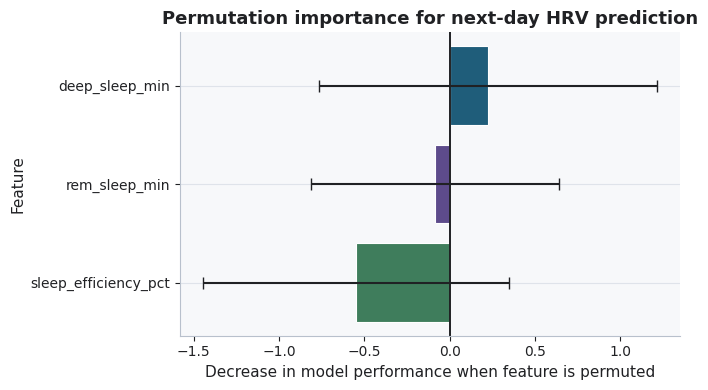

In [109]:
#XAI permutation importance

perm=permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=50,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)
perm_table = pd.DataFrame({
    "feature": required_features,
    "permutation_importance_mean": perm.importances_mean,
    "permutation_importance_std": perm.importances_std
}).sort_values("permutation_importance_mean", ascending=False)

display(perm_table)
plt.figure(figsize=(7,4))
values = perm_table["permutation_importance_mean"]
plt.barh(
    perm_table["feature"],
    values,
    xerr=perm_table["permutation_importance_std"],
    color=feature_bar_colors(perm_table["feature"]),
    edgecolor="white",
    linewidth=0.8,
    ecolor=COLORS["dark"],
    capsize=4
)
plt.axvline(0, linewidth=1.4, color=COLORS["dark"])
plt.title("Permutation importance for next-day HRV prediction")
plt.xlabel("Decrease in model performance when feature is permuted")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("permutation_importance.png")

,single_feature,test_MAE,test_RMSE,test_R2
1,rem_sleep_min,17.13722,17.317069,-49.539502
0,deep_sleep_min,17.39073,17.557526,-50.952782
2,sleep_efficiency_pct,17.58313,17.780622,-52.281458


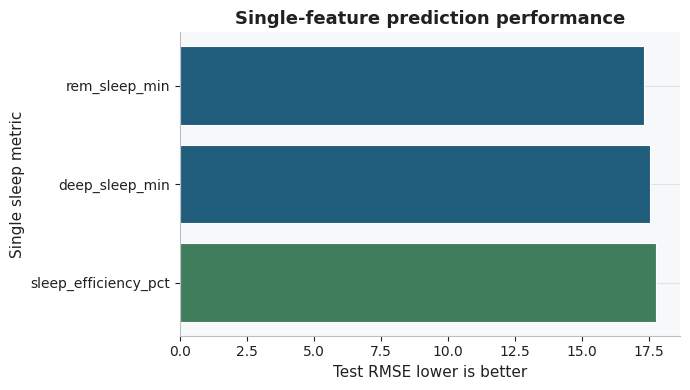

In [110]:
#single feature models
single_feature_rows = []
for feature in required_features:
    X_trainval_single = X_trainval[[feature]]
    X_test_single = X_test[[feature]]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    model.fit(X_trainval_single, y_trainval)
    pred = model.predict(X_test_single)
    metrics = regression_metrics(y_test, pred)

    single_feature_rows.append({
        "single_feature": feature,
        "test_MAE": metrics["MAE"],
        "test_RMSE": metrics["RMSE"],
        "test_R2": metrics["R2"]
    })
single_feature_results = pd.DataFrame(single_feature_rows).sort_values("test_RMSE")
display(single_feature_results)

plt.figure(figsize=(7,4))

best_rmse = single_feature_results["test_RMSE"].min()

bar_colors = [
    COLORS["blue"] if value == best_rmse else FEATURE_COLORS.get(feature, COLORS["orange"])
    for feature, value in zip(
        single_feature_results["single_feature"],
        single_feature_results["test_RMSE"]
    )
]
plt.barh(
    single_feature_results["single_feature"],
    single_feature_results["test_RMSE"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)
plt.title("Single-feature prediction performance")
plt.xlabel("Test RMSE lower is better")
plt.ylabel("Single sleep metric")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("single_feature_rmse.png")

In [111]:
corr_required = feature_selection_table[
    feature_selection_table["feature"].isin(required_features)
].copy()
corr_required = corr_required.rename(
    columns={"pearson_correlation_with_hrv": "pearson_r"}
)
influence_summary = corr_required.merge(
    coef_table[["feature", "standardized_linear_coefficient"]],
    on="feature",
    how="left"
).merge(
    perm_table[["feature", "permutation_importance_mean"]],
    on="feature",
    how="left"
)
influence_summary["abs_pearson_r"] = influence_summary["pearson_r"].abs()
influence_summary["abs_standardized_coefficient"] = influence_summary["standardized_linear_coefficient"].abs()

influence_summary = influence_summary.sort_values(
    ["permutation_importance_mean", "abs_standardized_coefficient", "abs_pearson_r"],
    ascending=False
).reset_index(drop=True)
display(influence_summary)
most_influential_feature = influence_summary.iloc[0]["feature"]

print(f"the most influential required sleep metric is {most_influential_feature}")
print()

,feature,pearson_r,standardized_linear_coefficient,permutation_importance_mean,abs_pearson_r,abs_standardized_coefficient
0,deep_sleep_min,-0.065054,-0.679863,0.224705,0.065054,0.679863
1,rem_sleep_min,-0.126519,-0.406452,-0.083651,0.126519,0.406452
2,sleep_efficiency_pct,-0.017608,0.709506,-0.550710,0.017608,0.709506


the most influential required sleep metric is deep_sleep_min



,model,fold,MAE,RMSE,R2
0,Linear Regression,1,8.793556,10.057882,-0.494293
1,Linear Regression,2,4.878645,6.387837,-0.213809
2,Linear Regression,3,14.749169,15.875074,-6.856676
3,Linear Regression,4,18.099558,18.356455,-38.739110
4,Linear Regression,5,17.455370,17.632179,-58.284675
5,Ridge Regression,1,8.795444,10.045264,-0.490546
6,Ridge Regression,2,4.868455,6.374125,-0.208604
7,Ridge Regression,3,14.752545,15.877124,-6.858705
8,Ridge Regression,4,18.094865,18.350994,-38.715471
9,Ridge Regression,5,17.452613,17.629055,-58.263666


MAE                 RMSE                   R2           
                               mean       std       mean       std       mean        std
model                                                                                   
Decision Tree Regression  13.562625  5.565236  14.862739  5.092505 -23.864292  30.485949
KNN Regression k=5        12.806244  5.160485  13.929183  4.875932 -20.966429  26.886500
Linear Regression         12.795260  5.752312  13.661886  5.210591 -20.917713  26.255345
Ridge Regression          12.792785  5.754139  13.655313  5.215952 -20.907398  26.245342

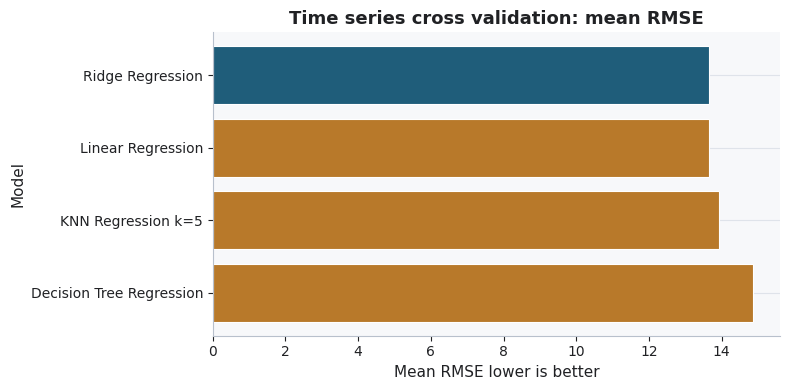

In [112]:
#time series cross validation
tscv = TimeSeriesSplit(n_splits=5)
cv_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "KNN Regression k=5": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5, weights="distance"))
    ]),
    "Decision Tree Regression": DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    )
}
cv_rows = []
for model_name, model in cv_models.items():
    fold_id = 1
    for train_idx, test_idx in tscv.split(X):
        X_cv_train, X_cv_test = X.iloc[train_idx], X.iloc[test_idx]
        y_cv_train, y_cv_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_cv_train, y_cv_train)
        pred = model.predict(X_cv_test)
        metrics = regression_metrics(y_cv_test, pred)

        cv_rows.append({
            "model": model_name,
            "fold": fold_id,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"]
        })

        fold_id +=1

cv_results = pd.DataFrame(cv_rows)
display(cv_results)

cv_summary = cv_results.groupby("model")[["MAE", "RMSE", "R2"]].agg(["mean", "std"])
display(cv_summary)

cv_rmse_plot = (
    cv_results
    .groupby("model")["RMSE"]
    .mean()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(8, 4))

plt.barh(
    cv_rmse_plot["model"],
    cv_rmse_plot["RMSE"],
    color=model_metric_colors(cv_rmse_plot["model"], cv_rmse_plot["RMSE"]),
    edgecolor="white",
    linewidth=0.8
)

plt.title("Time series cross validation: mean RMSE")
plt.xlabel("Mean RMSE lower is better")
plt.ylabel("Model")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("timeseries_cv_mean_rmse.png")

Low-HRV threshold based on train+validation Q1: 36.0
Train+validation class distribution:


,count
next_day_hrv_ms,
not_low_hrv,92
low_hrv,33


Test class distribution:


,count
next_day_hrv_ms,
low_hrv,32


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,model,accuracy,precision,recall,f1,roc_auc
3,Decision Tree Classifier,0.15625,1.0,0.15625,0.270270,NaN
1,KNN Classifier,0.06250,1.0,0.06250,0.117647,NaN
2,Gaussian Naive Bayes,0.03125,1.0,0.03125,0.060606,NaN
0,Dummy majority,0.00000,0.0,0.00000,0.000000,NaN


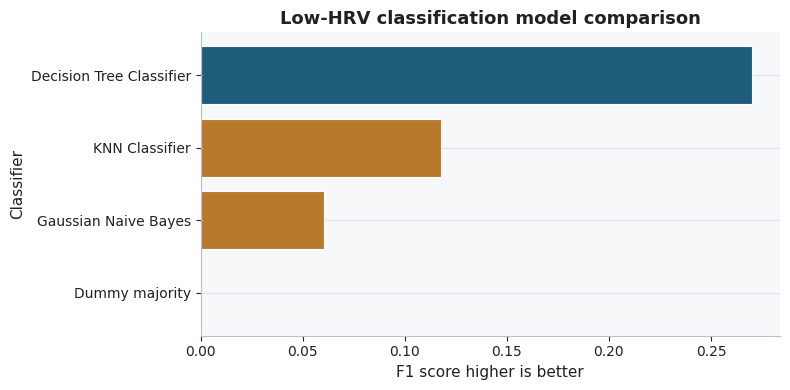

In [113]:
#low HRV risk classification
low_hrv_threshold = y_trainval.quantile(0.25)
print("Low-HRV threshold based on train+validation Q1:", low_hrv_threshold)

y_trainval_class = (y_trainval <= low_hrv_threshold).astype(int)
y_test_class = (y_test <= low_hrv_threshold).astype(int)
print("Train+validation class distribution:")
display(y_trainval_class.value_counts().rename({0: "not_low_hrv", 1: "low_hrv"}))
print("Test class distribution:")
display(y_test_class.value_counts().rename({0: "not_low_hrv", 1: "low_hrv"}))

classification_models = {
    "Dummy majority": DummyClassifier(strategy="most_frequent"),
    "KNN Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
    ]),
    "Gaussian Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    )
}

classification_rows=[]
for model_name, clf in classification_models.items():
    clf.fit(X_trainval, y_trainval_class)
    pred_class = clf.predict(X_test)

    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X_test)[:,1]
        try:
            auc = roc_auc_score(y_test_class, proba)
        except ValueError:
            auc = np.nan
    else:
        auc = np.nan
    classification_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test_class, pred_class),
        "precision": precision_score(y_test_class, pred_class, zero_division=0),
        "recall": recall_score(y_test_class, pred_class, zero_division=0),
        "f1": f1_score(y_test_class, pred_class, zero_division=0),
        "roc_auc": auc
    })

classification_results = pd.DataFrame(classification_rows).sort_values("f1", ascending=False)
display(classification_results)

#classification F1 comparison
plt.figure(figsize=(8,4))

plt.barh(
    classification_results["model"],
    classification_results["f1"],
    color=model_metric_colors(
        classification_results["model"],
        -classification_results["f1"]
    ),
    edgecolor="white",
    linewidth=0.8
)

plt.title("Low-HRV classification model comparison")
plt.xlabel("F1 score higher is better")
plt.ylabel("Classifier")
plt.gca().invert_yaxis()
polish_axes()
plt.tight_layout()
save_and_show_mlpr("low_hrv_classification_f1.png")

,Predicted not low HRV,Predicted low HRV
Actual not low HRV,0,0
Actual low HRV,27,5


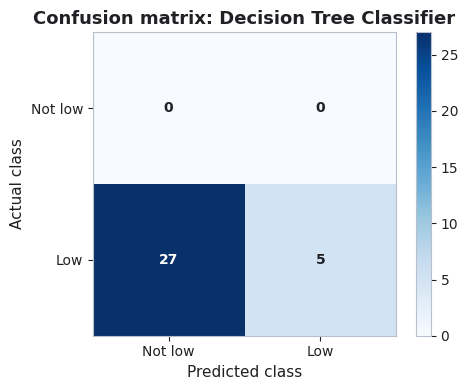

In [114]:
#low HRV classification, confusion matrix
best_classifier_name = classification_results.iloc[0]["model"]
best_classifier = classification_models[best_classifier_name]

best_classifier.fit(X_trainval, y_trainval_class)
best_class_pred = best_classifier.predict(X_test)

cm = confusion_matrix(y_test_class, best_class_pred, labels=[0, 1])

display(pd.DataFrame(
    cm,
    index=["Actual not low HRV", "Actual low HRV"],
    columns=["Predicted not low HRV", "Predicted low HRV"]
))

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion matrix: {best_classifier_name}")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks([0, 1], ["Not low", "Low"])
plt.yticks([0, 1], ["Not low", "Low"])

for i in range(2):
    for j in range(2):
        text_color = "white" if cm[i, j] > cm.max() / 2 else COLORS["dark"]
        plt.text(j, i, cm[i, j], ha="center", va="center", color=text_color, fontweight="bold")
plt.colorbar()
plt.tight_layout()
save_and_show_mlpr("low_hrv_confusion_matrix.png")

,deep_sleep_min,rem_sleep_min,sleep_efficiency_pct
not_low_hrv_prototype,-0.034656,-0.053421,0.018647
low_hrv_prototype,0.096617,0.148932,-0.051985


,model,accuracy,precision,recall,f1,classification_error
0,MED / nearest class prototype,0.59375,1.0,0.59375,0.745098,0.40625


Classification report for MED / prototype classifier:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.59      0.75        32

    accuracy                           0.59        32
   macro avg       0.50      0.30      0.37        32
weighted avg       1.00      0.59      0.75        32



,date,actual_low_hrv,predicted_low_hrv_MED,distance_to_not_low_hrv,distance_to_low_hrv
0,2026-04-02,1,0,1.148670,1.284271
1,2026-04-03,1,0,0.880174,0.998257
2,2026-04-04,1,0,1.258404,1.273616
3,2026-04-05,1,1,0.761779,0.705537
4,2026-04-06,1,0,1.023965,1.085340


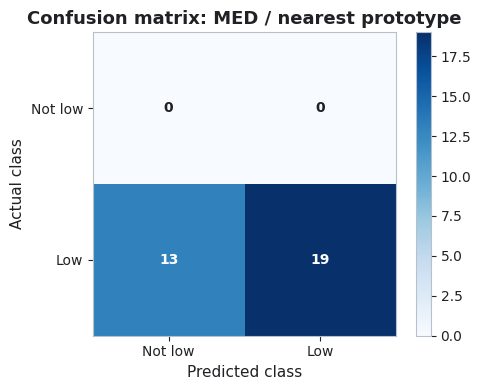

In [115]:
#prototype, MED classifier for Low HRV risk

from sklearn.metrics import classification_report

#scale features because Euclidean distance is sensitive to units
prototype_scaler = StandardScaler()

X_trainval_scaled = prototype_scaler.fit_transform(X_trainval)
X_test_scaled = prototype_scaler.transform(X_test)

X_trainval_scaled_df = pd.DataFrame(
    X_trainval_scaled,
    columns=required_features,
    index=X_trainval.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=required_features,
    index=X_test.index
)

#Class prototypes= mean vector of each class
prototypes = {}

for class_label in sorted(y_trainval_class.unique()):
    prototypes[class_label] = X_trainval_scaled_df[y_trainval_class == class_label].mean(axis=0).values

prototype_table = pd.DataFrame(
    prototypes,
    index=required_features
).T

prototype_table.index = prototype_table.index.map({
    0: "not_low_hrv_prototype",
    1: "low_hrv_prototype"
})

display(prototype_table)

def med_predict(X_scaled_array, prototypes_dict):
    predictions = []
    distance_rows = []

    for row in X_scaled_array:
        distances = {}

        for class_label, proto in prototypes_dict.items():
            distances[class_label] = np.linalg.norm(row - proto)

        predicted_class = min(distances, key=distances.get)
        predictions.append(predicted_class)

        distance_rows.append({
            "distance_to_not_low_hrv": distances.get(0, np.nan),
            "distance_to_low_hrv": distances.get(1, np.nan)
        })

    return np.array(predictions), pd.DataFrame(distance_rows)

med_pred, med_distances = med_predict(X_test_scaled, prototypes)

med_results = {
    "model": "MED / nearest class prototype",
    "accuracy": accuracy_score(y_test_class, med_pred),
    "precision": precision_score(y_test_class, med_pred, zero_division=0),
    "recall": recall_score(y_test_class, med_pred, zero_division=0),
    "f1": f1_score(y_test_class, med_pred, zero_division=0),
    "classification_error": 1 - accuracy_score(y_test_class, med_pred)
}

display(pd.DataFrame([med_results]))

print("Classification report for MED / prototype classifier:")
print(classification_report(y_test_class, med_pred, zero_division=0))

med_prediction_table = pd.DataFrame({
    "date": dates_test.values,
    "actual_low_hrv": y_test_class.values,
    "predicted_low_hrv_MED": med_pred
}).reset_index(drop=True)

med_prediction_table = pd.concat([med_prediction_table, med_distances], axis=1)

display(med_prediction_table.head())

cm_med = confusion_matrix(y_test_class, med_pred)

plt.figure(figsize=(5, 4))

plt.imshow(cm_med, cmap="Blues")

plt.title("Confusion matrix: MED / nearest prototype")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.xticks([0, 1], ["Not low", "Low"])
plt.yticks([0, 1], ["Not low", "Low"])

for i in range(2):
    for j in range(2):
        text_color = "white" if cm_med[i, j] > cm_med.max() / 2 else COLORS["dark"]
        plt.text(j, i, cm_med[i, j], ha="center", va="center", color=text_color, fontweight="bold")

plt.colorbar()
plt.tight_layout()
save_and_show_mlpr("med_prototype_confusion_matrix.png")

In [116]:
#gaussian ML and MAP classifiers

def regularized_covariance(X_class, eps=1e-4):
    cov = np.cov(X_class, rowvar=False)

    if cov.ndim == 0:
        cov = np.array([[cov]])

    cov = cov + eps * np.eye(cov.shape[0])
    return cov

def log_multivariate_normal_pdf(X_array, mean, cov):
    n_features = X_array.shape[1]
    inv_cov = np.linalg.inv(cov)
    sign, log_det = np.linalg.slogdet(cov)

    if sign <= 0:
        raise ValueError("Covariance matrix is not positive definite.")

    diff = X_array - mean
    quadratic = np.sum(diff @ inv_cov * diff, axis=1)

    log_pdf = -0.5 * (
        n_features * np.log(2 * np.pi) +
        log_det +
        quadratic
    )

    return log_pdf

#gaussian class models from train+validation only
gaussian_models={}

for class_label in sorted(y_trainval_class.unique()):
    X_class = X_trainval_scaled[y_trainval_class == class_label]

    gaussian_models[class_label]={
        "mean": X_class.mean(axis=0),
        "cov": regularized_covariance(X_class),
        "prior": len(X_class) / len(X_trainval_scaled)
    }

gaussian_summary_rows=[]

for class_label, params in gaussian_models.items():
    for idx, feature in enumerate(required_features):
        gaussian_summary_rows.append({
            "class": class_label,
            "class_name": "low_hrv" if class_label ==1 else "not_low_hrv",
            "feature": feature,
            "mean_scaled": params["mean"][idx],
            "prior_probability": params["prior"]
        })

gaussian_summary = pd.DataFrame(gaussian_summary_rows)
display(gaussian_summary)
def gaussian_classifier_predict(X_array, gaussian_models, use_priors):
    score_matrix=[]
    for class_label, params in gaussian_models.items():
        log_likelihood = log_multivariate_normal_pdf(
            X_array,
            params["mean"],
            params["cov"]
        )
        if use_priors:
            score = log_likelihood + np.log(params["prior"])
        else:
            score = log_likelihood
        score_matrix.append(score)
    score_matrix = np.vstack(score_matrix).T
    class_labels = np.array(sorted(gaussian_models.keys()))

    predictions = class_labels[np.argmax(score_matrix, axis=1)]
    return predictions, score_matrix

#ML classifier with class with highest likelihood p(x|Ck)
ml_pred, ml_scores = gaussian_classifier_predict(
    X_test_scaled,
    gaussian_models,
    use_priors=False
)

#MAP classifier choose class with highest posterior proportional to p(x|Ck)P(Ck)
map_pred, map_scores = gaussian_classifier_predict(
    X_test_scaled,
    gaussian_models,
    use_priors=True
)
gaussian_classifier_results = pd.DataFrame([
    {
        "model": "Gaussian ML classifier",
        "accuracy": accuracy_score(y_test_class, ml_pred),
        "precision": precision_score(y_test_class, ml_pred, zero_division=0),
        "recall": recall_score(y_test_class, ml_pred, zero_division=0),
        "f1": f1_score(y_test_class, ml_pred, zero_division=0),
        "classification_error": 1 - accuracy_score(y_test_class, ml_pred)
    },
    {
        "model": "Gaussian MAP classifier",
        "accuracy": accuracy_score(y_test_class, map_pred),
        "precision": precision_score(y_test_class, map_pred, zero_division=0),
        "recall": recall_score(y_test_class, map_pred, zero_division=0),
        "f1": f1_score(y_test_class, map_pred, zero_division=0),
        "classification_error": 1 - accuracy_score(y_test_class, map_pred)
    }
])

display(gaussian_classifier_results)
print("ML classifier report:")
print(classification_report(y_test_class, ml_pred, zero_division=0))
print("MAP classifier report:")
print(classification_report(y_test_class, map_pred, zero_division=0))

,class,class_name,feature,mean_scaled,prior_probability
0,0,not_low_hrv,deep_sleep_min,-0.034656,0.736
1,0,not_low_hrv,rem_sleep_min,-0.053421,0.736
2,0,not_low_hrv,sleep_efficiency_pct,0.018647,0.736
3,1,low_hrv,deep_sleep_min,0.096617,0.264
4,1,low_hrv,rem_sleep_min,0.148932,0.264
5,1,low_hrv,sleep_efficiency_pct,-0.051985,0.264


,model,accuracy,precision,recall,f1,classification_error
0,Gaussian ML classifier,0.40625,1.0,0.40625,0.577778,0.59375
1,Gaussian MAP classifier,0.00000,0.0,0.00000,0.000000,1.00000


ML classifier report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.41      0.58        32

    accuracy                           0.41        32
   macro avg       0.50      0.20      0.29        32
weighted avg       1.00      0.41      0.58        32

MAP classifier report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00      32.0

    accuracy                           0.00      32.0
   macro avg       0.00      0.00      0.00      32.0
weighted avg       0.00      0.00      0.00      32.0



,class,deep_sleep_scaled,rem_sleep_scaled,source
0,0,-0.392894,-0.518453,synthetic
1,0,-1.352605,0.274306,synthetic
2,0,0.283730,0.001652,synthetic
3,0,-1.776528,-0.869973,synthetic
4,0,0.098198,0.611983,synthetic


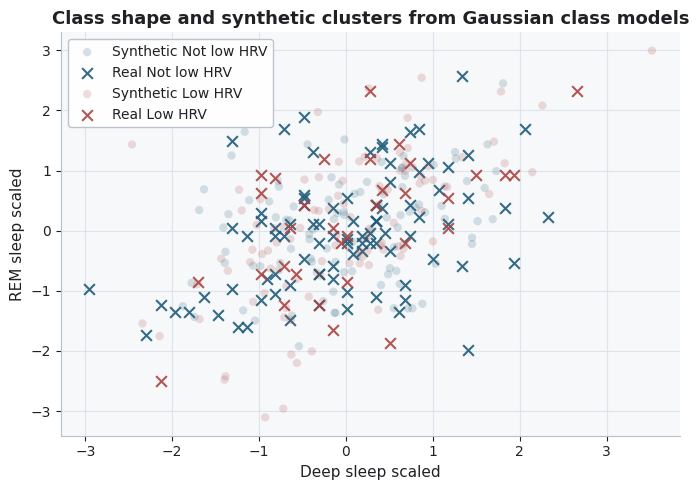

In [117]:
#class shape and synthetic cluster visualization

feature_x = "deep_sleep_min"
feature_y = "rem_sleep_min"

vis_features=[feature_x, feature_y]

vis_scaler = StandardScaler()
X_trainval_vis_scaled = vis_scaler.fit_transform(X_trainval[vis_features])
X_test_vis_scaled = vis_scaler.transform(X_test[vis_features])

#2D Gaussian models
gaussian_vis_models={}

for class_label in sorted(y_trainval_class.unique()):
    X_class = X_trainval_vis_scaled[y_trainval_class == class_label]

    gaussian_vis_models[class_label]={
        "mean": X_class.mean(axis=0),
        "cov": regularized_covariance(X_class),
        "prior": len(X_class) / len(X_trainval_vis_scaled)
    }
np.random.seed(42)
synthetic_rows=[]
for class_label, params in gaussian_vis_models.items():
    synthetic_points = np.random.multivariate_normal(
        mean=params["mean"],
        cov=params["cov"],
        size=100
    )
    for point in synthetic_points:
        synthetic_rows.append({
            "class": class_label,
            "deep_sleep_scaled": point[0],
            "rem_sleep_scaled": point[1],
            "source": "synthetic"
        })

synthetic_df = pd.DataFrame(synthetic_rows)
real_vis_df = pd.DataFrame({
    "class": y_trainval_class.values,
    "deep_sleep_scaled": X_trainval_vis_scaled[:,0],
    "rem_sleep_scaled": X_trainval_vis_scaled[:,1],
    "source": "real"
})

display(synthetic_df.head())
plt.figure(figsize=(7,5))
for class_label in sorted(real_vis_df["class"].unique()):
    tmp_real = real_vis_df[real_vis_df["class"] == class_label]
    tmp_syn = synthetic_df[synthetic_df["class"] == class_label]

    label_name ="Low HRV" if class_label == 1 else "Not low HRV"
    plt.scatter(
        tmp_syn["deep_sleep_scaled"],
        tmp_syn["rem_sleep_scaled"],
        alpha=0.18,
        color=COLORS["red"] if class_label == 1 else COLORS["blue"],
        edgecolor="none",
        label=f"Synthetic {label_name}"
    )

    plt.scatter(
        tmp_real["deep_sleep_scaled"],
        tmp_real["rem_sleep_scaled"],
        alpha=0.90,
        marker="x",
        s=60,
        color=COLORS["red"] if class_label == 1 else COLORS["blue"],
        label=f"Real {label_name}"
    )

plt.title("Class shape and synthetic clusters from Gaussian class models")
plt.xlabel("Deep sleep scaled")
plt.ylabel("REM sleep scaled")
plt.legend()
polish_axes(grid_axis="both")
plt.tight_layout()
save_and_show_mlpr("class_shape_synthetic_clusters.png")

,class,deep_sleep_scaled,rem_sleep_scaled,source
0,0,-0.392894,-0.518453,synthetic
1,0,-1.352605,0.274306,synthetic
2,0,0.283730,0.001652,synthetic
3,0,-1.776528,-0.869973,synthetic
4,0,0.098198,0.611983,synthetic


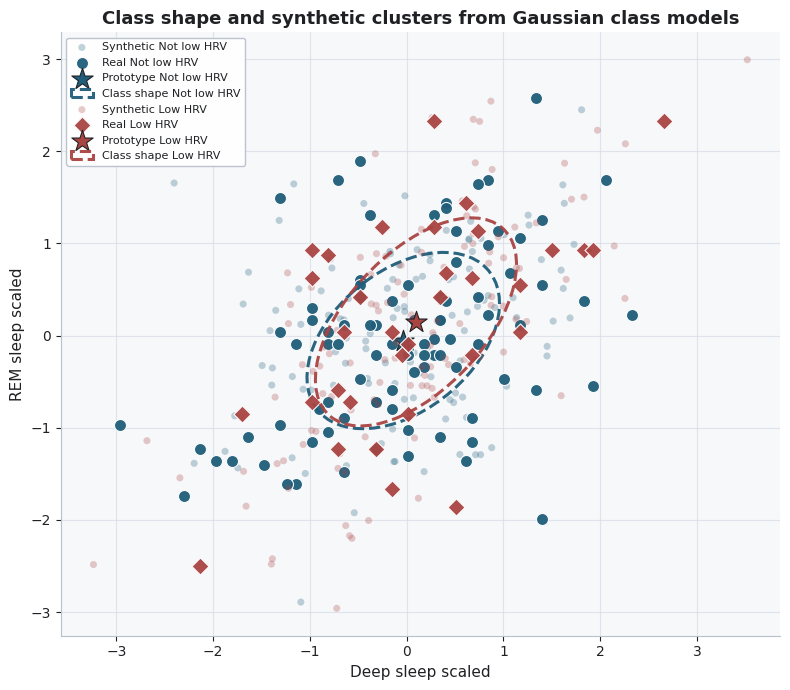

In [118]:
from matplotlib.patches import Ellipse
feature_x = "deep_sleep_min"
feature_y = "rem_sleep_min"

vis_features= [feature_x, feature_y]
vis_scaler = StandardScaler()
X_trainval_vis_scaled = vis_scaler.fit_transform(X_trainval[vis_features])
X_test_vis_scaled = vis_scaler.transform(X_test[vis_features])
gaussian_vis_models = {}

for class_label in sorted(y_trainval_class.unique()):
    X_class = X_trainval_vis_scaled[y_trainval_class == class_label]

    gaussian_vis_models[class_label] = {
        "mean": X_class.mean(axis=0),
        "cov": regularized_covariance(X_class),
        "prior": len(X_class) / len(X_trainval_vis_scaled)
    }
np.random.seed(42)

synthetic_rows=[]

for class_label, params in gaussian_vis_models.items():
    synthetic_points = np.random.multivariate_normal(
        mean=params["mean"],
        cov=params["cov"],
        size=120
    )
    for point in synthetic_points:
        synthetic_rows.append({
            "class": class_label,
            "deep_sleep_scaled": point[0],
            "rem_sleep_scaled": point[1],
            "source": "synthetic"
        })

synthetic_df= pd.DataFrame(synthetic_rows)
real_vis_df = pd.DataFrame({
    "class": y_trainval_class.values,
    "deep_sleep_scaled": X_trainval_vis_scaled[:, 0],
    "rem_sleep_scaled": X_trainval_vis_scaled[:, 1],
    "source": "real"
})

display(synthetic_df.head())
CLASS_COLORS={
    0: COLORS.get("blue", "#1F5D7A"),
    1: COLORS.get("red", "#A94442")
}

CLASS_MARKERS={
    0: "o",
    1: "D"
}

def add_covariance_ellipse(mean, cov, color, label=None):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2* np.sqrt(eigenvalues)
    ellipse= Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        facecolor="none",
        edgecolor=color,
        linewidth=2.2,
        linestyle="--",
        alpha=0.95,
        label=label
    )

    plt.gca().add_patch(ellipse)

plt.figure(figsize=(8,7))
for class_label in sorted(real_vis_df["class"].unique()):
    tmp_real = real_vis_df[real_vis_df["class"] == class_label]
    tmp_syn = synthetic_df[synthetic_df["class"] == class_label]

    label_name = "Low HRV" if class_label ==1 else "Not low HRV"
    class_color=CLASS_COLORS[class_label]
    plt.scatter(
        tmp_syn["deep_sleep_scaled"],
        tmp_syn["rem_sleep_scaled"],
        alpha=0.28,
        s=26,
        color=class_color,
        edgecolor="none",
        label=f"Synthetic {label_name}"
    )
    plt.scatter(
        tmp_real["deep_sleep_scaled"],
        tmp_real["rem_sleep_scaled"],
        alpha=0.95,
        marker=CLASS_MARKERS[class_label],
        s=75,
        color=class_color,
        edgecolor="white",
        linewidth=0.8,
        label=f"Real {label_name}"
    )

    mean_point = gaussian_vis_models[class_label]["mean"]

    plt.scatter(
        mean_point[0],
        mean_point[1],
        marker="*",
        s=260,
        color=class_color,
        edgecolor=COLORS.get("dark", "#202124"),
        linewidth=0.8,
        label=f"Prototype {label_name}"
    )

    add_covariance_ellipse(
    mean=gaussian_vis_models[class_label]["mean"],
    cov=gaussian_vis_models[class_label]["cov"],
    color=class_color,
    label=f"Class shape {label_name}"
    )

plt.title("Class shape and synthetic clusters from Gaussian class models")
plt.xlabel("Deep sleep scaled")
plt.ylabel("REM sleep scaled")
plt.legend(loc="best", fontsize=8)
polish_axes(grid_axis="both")
plt.tight_layout()
save_and_show_mlpr("class_shape_synthetic_clusters.png")

,model,accuracy,precision,recall,f1,roc_auc,classification_error
0,MED / nearest class prototype,0.59375,1.0,0.59375,0.745098,NaN,0.40625
1,Gaussian ML classifier,0.40625,1.0,0.40625,0.577778,NaN,0.59375
2,Decision Tree Classifier,0.15625,1.0,0.15625,0.270270,NaN,0.84375
3,KNN Classifier,0.06250,1.0,0.06250,0.117647,NaN,0.93750
4,Gaussian Naive Bayes,0.03125,1.0,0.03125,0.060606,NaN,0.96875
5,Dummy majority,0.00000,0.0,0.00000,0.000000,NaN,1.00000
6,Gaussian MAP classifier,0.00000,0.0,0.00000,0.000000,NaN,1.00000


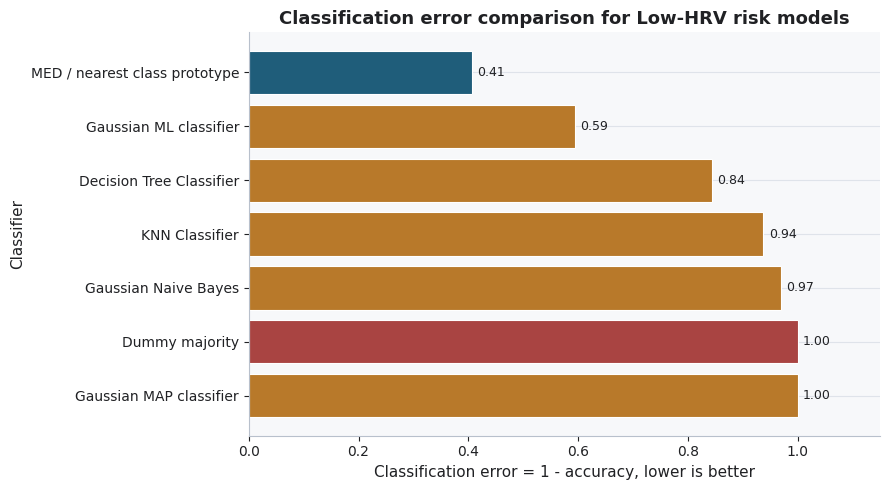

In [119]:
#classification error summary

extra_classification_results = pd.concat([
    pd.DataFrame([med_results]),
    gaussian_classifier_results
], ignore_index=True)

classification_results_extended = pd.concat([
    classification_results.assign(
        classification_error=1 - classification_results["accuracy"]
    ),
    extra_classification_results
], ignore_index=True)

classification_results_extended = classification_results_extended.sort_values(
    "classification_error"
).reset_index(drop=True)

display(classification_results_extended)
best_idx = classification_results_extended["classification_error"].idxmin()
worst_idx = classification_results_extended["classification_error"].idxmax()

bar_colors=[]

for idx, row in classification_results_extended.iterrows():
    model_name = str(row["model"])

    if idx == best_idx:
        bar_colors.append(COLORS.get("blue", "#1F5D7A"))
    elif idx == worst_idx and best_idx != worst_idx:
        bar_colors.append(COLORS.get("red", "#A94442"))
    elif "Dummy" in model_name or "majority" in model_name:
        bar_colors.append(COLORS.get("gray", "#5F6368"))
    else:
        bar_colors.append(COLORS.get("orange", "#B8792A"))
plt.figure(figsize=(9,5))

bars = plt.barh(
    classification_results_extended["model"],
    classification_results_extended["classification_error"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

plt.title("Classification error comparison for Low-HRV risk models")
plt.xlabel("Classification error = 1 - accuracy, lower is better")
plt.ylabel("Classifier")
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9,
        color=COLORS.get("dark", "#202124")
    )

plt.xlim(0, max(1.0, classification_results_extended["classification_error"].max() +0.15))
polish_axes()
plt.tight_layout()
save_and_show_mlpr("classification_error_comparison.png")
classification_results_extended.to_csv(
    "mlpr_low_hrv_classification_results_extended.csv",
    index=False
)

In [120]:
print(classification_results.to_string(index=False))

                   model  accuracy  precision  recall       f1  roc_auc
Decision Tree Classifier   0.15625        1.0 0.15625 0.270270      NaN
          KNN Classifier   0.06250        1.0 0.06250 0.117647      NaN
    Gaussian Naive Bayes   0.03125        1.0 0.03125 0.060606      NaN
          Dummy majority   0.00000        0.0 0.00000 0.000000      NaN


In [121]:
print(cv_rmse_plot.to_string(index=False))

                   model      RMSE
        Ridge Regression 13.655313
       Linear Regression 13.661886
      KNN Regression k=5 13.929183
Decision Tree Regression 14.862739


In [122]:
print(feature_selection_table.head(5).to_string(index=False))

                 feature  pearson_correlation_with_hrv
      avg_heart_rate_bpm                     -0.922618
awake_pct_of_time_in_bed                     -0.289665
            avg_spo2_pct                      0.286290
               awake_min                     -0.240067
       calories_prev_day                      0.210334


In [123]:
validation_results.to_csv("mlpr_validation_results.csv", index=False)
tuning_results.to_csv("mlpr_tuning_results.csv", index=False)
test_comparison.to_csv("mlpr_test_model_comparison.csv", index=False)
test_results.to_csv("mlpr_best_model_test_results.csv", index=False)
prediction_results.to_csv("mlpr_test_predictions.csv", index=False)
coef_table.to_csv("mlpr_standardized_coefficients.csv", index=False)
perm_table.to_csv("mlpr_permutation_importance.csv", index=False)
single_feature_results.to_csv("mlpr_single_feature_results.csv", index=False)
influence_summary.to_csv("mlpr_feature_influence_summary.csv", index=False)
cv_results.to_csv("mlpr_timeseries_cv_results.csv", index=False)
classification_results.to_csv("mlpr_low_hrv_classification_results.csv", index=False)
prototype_table.to_csv("mlpr_class_prototypes.csv", index=True)
med_prediction_table.to_csv("mlpr_med_prototype_predictions.csv", index=False)
gaussian_summary.to_csv("mlpr_gaussian_class_model_summary.csv", index=False)
gaussian_classifier_results.to_csv("mlpr_gaussian_ml_map_results.csv", index=False)
classification_results_extended.to_csv("mlpr_low_hrv_classification_results_extended.csv", index=False)
cluster_quality.to_csv("cda_kmeans_cluster_quality.csv", index=False)

print("Saved MLPR output files.")
print(f"Figures saved in folder: {FIG_DIR_MLPR}")

Saved MLPR output files.
Figures saved in folder: figures_mlpr
